In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
import yaml
import re

import keypoint_moseq as kpms

In [2]:
# Groups

Agg = ["975826", "975827", "975833", "978772", "978774", "988590", "997838", "1010820", "1010823", "1010826", "1029741"]
nonAgg = ["975830", "978775", "1010819", "997839", "997840", "997841", "1029736", "1029739", "1032216"]
maladaptive = ["978513", "978527", "978528", "1010832", "1013590", "1034805", "1034814", "1079919", "1079907", "1055495", "1075472", "1106648"]

In [ ]:
kpmoseq_dir = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingSessions_topView_KPMS_Resident_v3"
model = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingSessions_topView_KPMS_Resident_v3\fullModel_100000.0"
results = kpms.load_results(kpmoseq_dir, model)

config = lambda: kpms.load_config(kpmoseq_dir)

Models:  [Path('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_DLC_multiAnimal/trainingSessions_topView_KPMS_Resident_v3/fullModel_10000.0'), Path('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_DLC_multiAnimal/trainingSessions_topView_KPMS_Resident_v3/fullModel_100000.0'), Path('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_DLC_multiAnimal/trainingSessions_topView_KPMS_Resident_v3/fullModel_1000000.0'), Path('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_DLC_multiAnimal/trainingSessions_topView_KPMS_Resident_v3/fullModel_10000000.0')]


100%|█████████████████████████████████████| 4/4 [03:50<00:00, 57.69s/it]



Best model: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingSessions_topView_KPMS_Resident_v3\fullModel_100000.0


(<Figure size 400x350 with 1 Axes>, <Axes: ylabel='EML score'>)

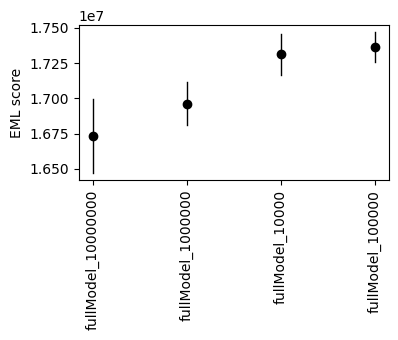

In [267]:
model_names = [f for f in Path(kpmoseq_dir).rglob("fullModel*")]
print("Models: ", model_names)

eml_scores, eml_std_errs = kpms.expected_marginal_likelihoods(kpmoseq_dir, model_names)
best_model = model_names[np.argmax(eml_scores)]
print(f"\nBest model: {best_model}")

kpms.plot_eml_scores(eml_scores, eml_std_errs, [str(Path(f).stem) for f in model_names])

In [512]:
train_results = kpms.load_results(kpmoseq_dir, model, r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingSessions_topView_KPMS_Resident\fullModel_100000.0\firstIteration_results.h5")

In [210]:
dlc_h5_folder = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingSessions_topView_DLC_multiAnimal")

allData = [str(f) for f in dlc_h5_folder.rglob(r"*.h5") if "excluded" not in str(f) and "filtered" not in str(f)]

h5_files_filtered = [
    f for f in allData
    if "transformer" not in f or f.endswith("_sk_tr.h5")
]

allData = h5_files_filtered
allData

['C:\\Users\\stagk\\OneDrive\\Desktop\\trainingAggression_MR\\trainingSessions\\trainingSessions_topView_DLC_multiAnimal\\trainingSessions_topView_DLC_multiAnimal\\mouse1010819\\topView_DLCtracking_pcutoff_0.8_skeleton\\mouse1010819_Day02_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk.h5',
 'C:\\Users\\stagk\\OneDrive\\Desktop\\trainingAggression_MR\\trainingSessions\\trainingSessions_topView_DLC_multiAnimal\\trainingSessions_topView_DLC_multiAnimal\\mouse1010819\\topView_DLCtracking_pcutoff_0.8_skeleton\\mouse1010819_Day04_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk.h5',
 'C:\\Users\\stagk\\OneDrive\\Desktop\\trainingAggression_MR\\trainingSessions\\trainingSessions_topView_DLC_multiAnimal\\trainingSessions_topView_DLC_multiAnimal\\mouse1010819\\topView_DLCtracking_pcutoff_0.8_skeleton\\mouse1010819_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topVi

In [211]:
exclude = ["Intruder","single"]

coordinates, confidences, bodyparts = kpms.load_keypoints(allData, 
                                                          "deeplabcut", 
                                                          path_in_name=True, 
                                                          exclude_individuals=exclude)

Loading keypoints:   1%|▏               | 4/283 [00:00<00:15, 18.56it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints:   4%|▌              | 10/283 [00:00<00:13, 20.64it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints:   5%|▋              | 13/283 [00:00<00:13, 20.29it/s]

...

Loading keypoints: 100%|█████████████▉| 282/283 [00:13<00:00, 21.36it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints: 100%|██████████████| 283/283 [00:13<00:00, 20.35it/s]


Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.



Coordinates for the following bodyparts are missing (set to NaN) in at least 50.0% of frames:
 - midPoint

This may cause problems during modeling. See https://keypoint-moseq.readthedocs.io/en/latest/FAQs.html#high-proportion-of-nans for additional information.

In [212]:
def extract_id(k):
    m = re.search(r"(mouse\d+).*?Day(\d+)", k)
    if not m:
        return None
    return f"{m.group(1)}_Day{m.group(2)}"

def clean_keys(d):
    new_d = {}
    for k, v in d.items():
        new_key = extract_id(k)
        if new_key is None:
            continue  # or raise error if you prefer
        new_d[new_key] = v
    return new_d

In [217]:
config()

{'bodyparts': ['nose',
  'rightEar',
  'leftEar',
  'neckBase',
  'betNeckBaseAndMidPoint',
  'midPoint',
  'betMidPointAndTailBase',
  'tailBase',
  'tailMid',
  'tailTip'],
 'use_bodyparts': ['nose',
  'rightEar',
  'leftEar',
  'neckBase',
  'betNeckBaseAndMidPoint',
  'midPoint',
  'betMidPointAndTailBase',
  'tailBase',
  'tailMid',
  'tailTip'],
 'skeleton': [['nose', 'leftEar'],
  ['nose', 'rightEar'],
  ['leftEar', 'neckBase'],
  ['rightEar', 'neckBase'],
  ['leftEar', 'betNeckBaseAndMidPoint'],
  ['rightEar', 'betNeckBaseAndMidPoint'],
  ['neckBase', 'betNeckBaseAndMidPoint'],
  ['betNeckBaseAndMidPoint', 'midPoint'],
  ['midPoint', 'betMidPointAndTailBase'],
  ['betMidPointAndTailBase', 'tailBase'],
  ['tailBase', 'tailMid'],
  ['tailMid', 'tailTip']],
 'anterior_bodyparts': ['nose', 'leftEar', 'rightEar', 'neckBase'],
 'posterior_bodyparts': ['betNeckBaseAndMidPoint',
  'midPoint',
  'betMidPointAndTailBase',
  'tailBase',
  'tailMid',
  'tailTip'],
 'added_noise_level': 0.1

In [218]:
coordinates = clean_keys(coordinates)
confidences = clean_keys(confidences)

coordinates, confidences = kpms.outlier_removal(coordinates,
                                                confidences,
                                                kpmoseq_dir,
                                                overwrite=False,
                                                **config())

In [219]:
model_name = str(Path(model).stem) + ".0"

Saving trajectory plots to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingSessions_topView_KPMS_Resident_v3\fullModel_100000.0\trajectory_plots


Generating trajectory plots: 100%|██████| 31/31 [00:22<00:00,  1.35it/s]


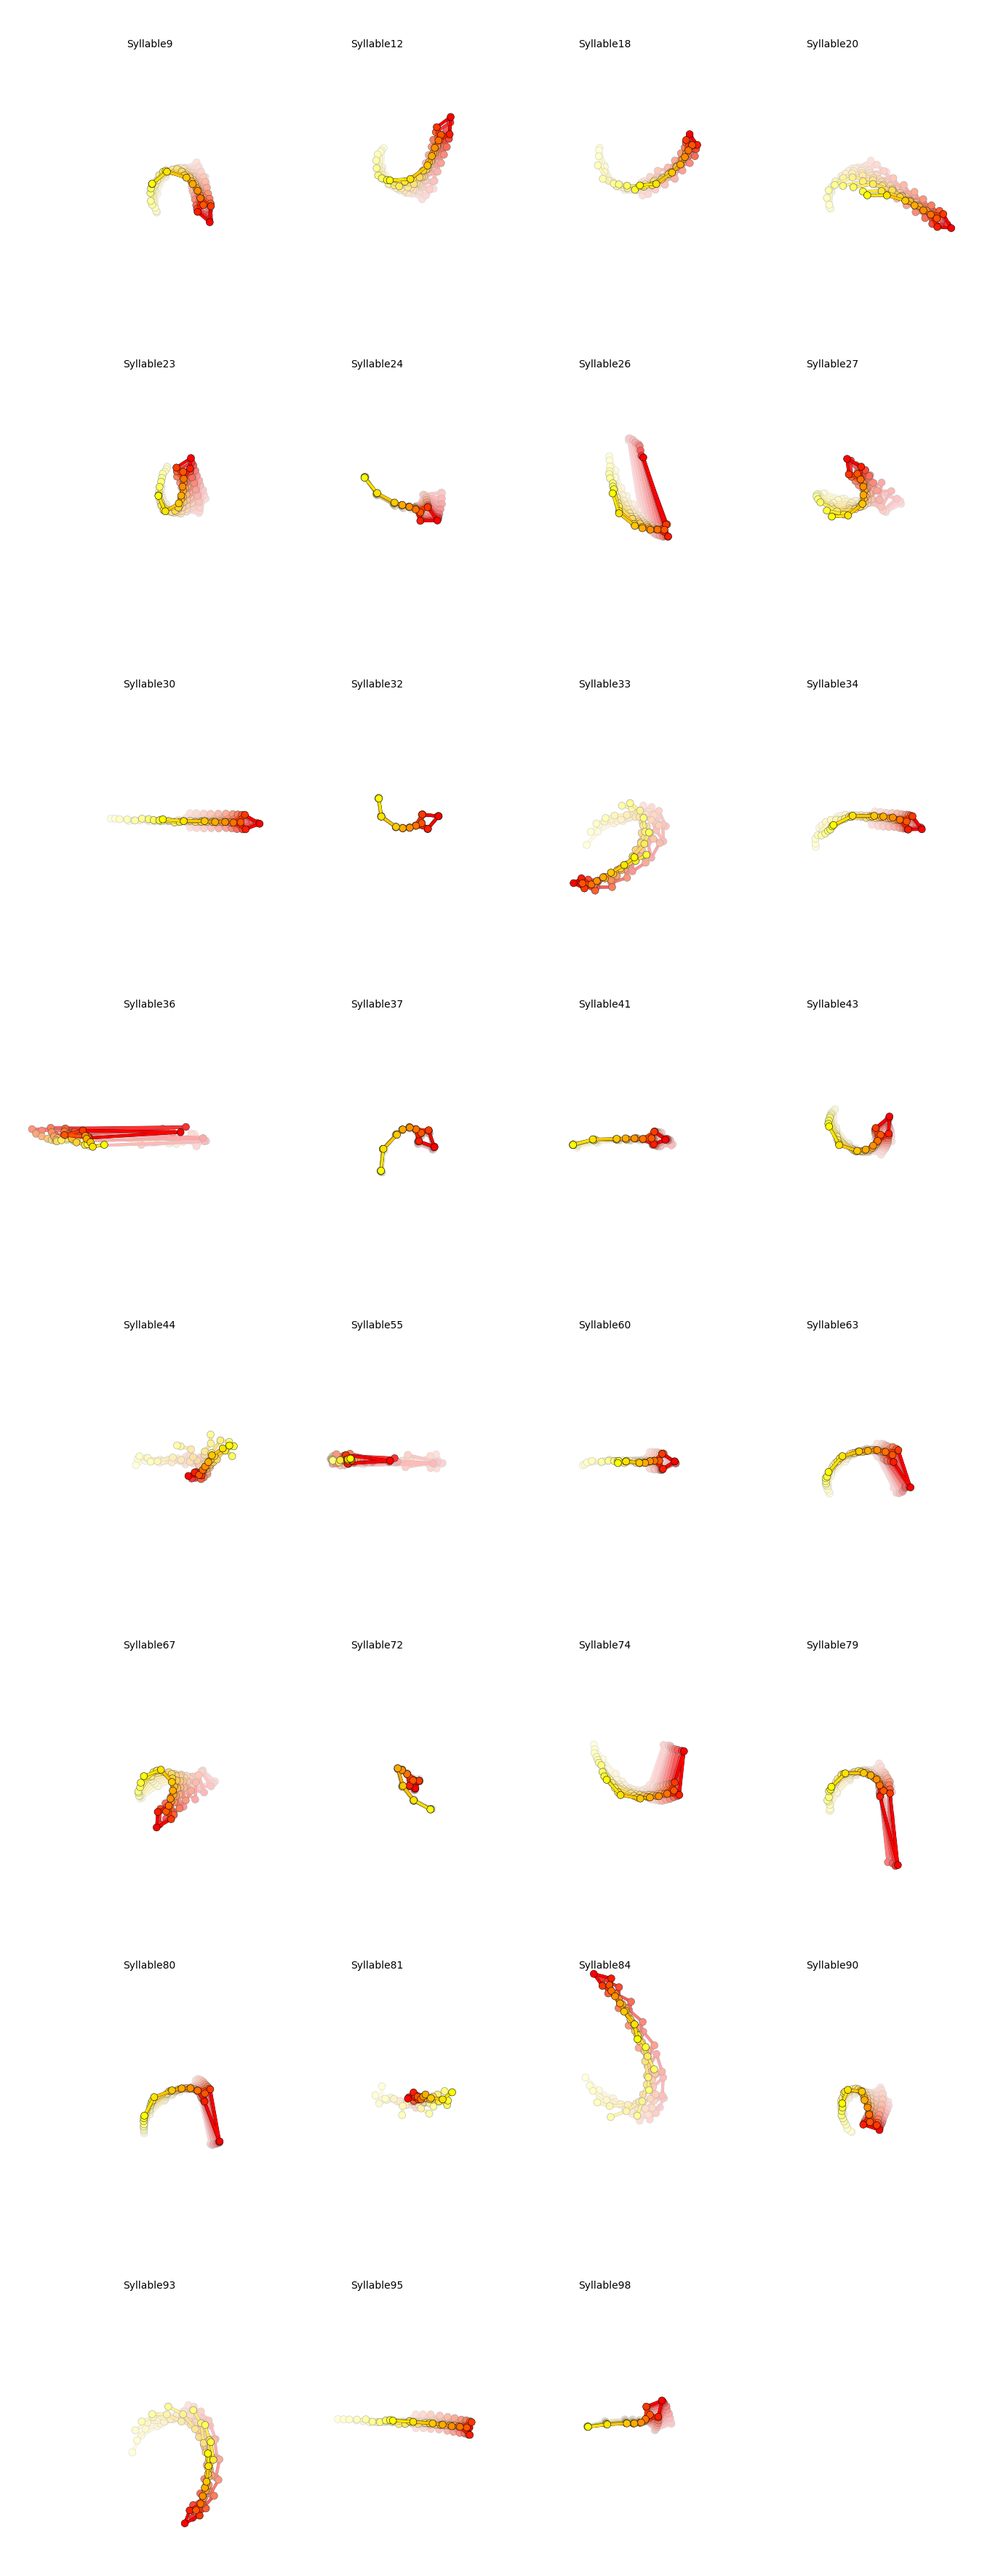

In [220]:

kpms.generate_trajectory_plots(coordinates = coordinates, 
                               results = results, 
                               project_dir = kpmoseq_dir, 
                               model_name = model_name, 
                               get_limits_pctl = 0,
                               **config())

Array([7, 8, 9], dtype=int64)

Mean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empty sliceMean of empt

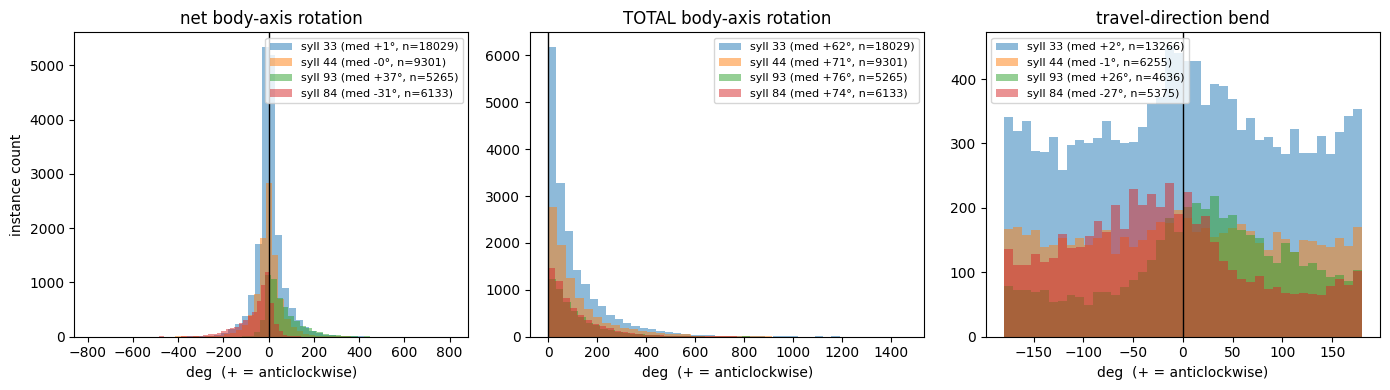

syll  33 | net body   : median    +1.3°  IQR [-19, +26]°  n=18029
syll  33 | total body : median   +62.1°  IQR [+22, +147]°  n=18029
syll  33 | travel bend: median    +2.3°  IQR [-82, +83]°  n=13266
syll  44 | net body   : median    -0.2°  IQR [-25, +26]°  n=9301
syll  44 | total body : median   +71.2°  IQR [+31, +156]°  n=9301
syll  44 | travel bend: median    -0.8°  IQR [-88, +85]°  n=6255
syll  93 | net body   : median   +37.3°  IQR [+7, +92]°  n=5265
syll  93 | total body : median   +76.3°  IQR [+33, +152]°  n=5265
syll  93 | travel bend: median   +26.1°  IQR [-33, +86]°  n=4636
syll  84 | net body   : median   -30.7°  IQR [-88, -3]°  n=6133
syll  84 | total body : median   +73.6°  IQR [+31, +152]°  n=6133
syll  84 | travel bend: median   -26.9°  IQR [-88, +35]°  n=5375


In [265]:
SYLLS = [33, 44, 93, 84]
ANT, POST = config()["anterior_idxs"], config()["posterior_idxs"][3:]

def body_heading(xy):                       # nose->tail body axis (uses nose; noisy here)
    a = np.nanmean(xy[:, ANT, :], axis=1); p = np.nanmean(xy[:, POST, :], axis=1)
    v = a - p
    return np.arctan2(v[:, 1], v[:, 0])

def net_rot(theta):                          # signed end-minus-start (rad)
    theta = theta[np.isfinite(theta)]
    if theta.size < 2: return np.nan
    u = np.unwrap(theta); return u[-1] - u[0]

def total_rot(theta):                        # cumulative |turning|, catches turns that net out
    theta = theta[np.isfinite(theta)]
    if theta.size < 2: return np.nan
    return np.sum(np.abs(np.diff(np.unwrap(theta))))

def travel_bend(xy):                         # change in direction of TRAVEL (centroid; nose-free)
    c = np.nanmean(xy, axis=1)               # (T,2) centroid
    c = pd.DataFrame(c).interpolate(limit_direction="both").to_numpy()
    if len(c) < 6: return np.nan
    k = max(1, len(c) // 3)
    v0 = c[k] - c[0]; v1 = c[-1] - c[-1 - k] # early vs late travel vector
    a0 = np.arctan2(v0[1], v0[0]); a1 = np.arctan2(v1[1], v1[0])
    return (a1 - a0 + np.pi) % (2 * np.pi) - np.pi   # signed, wrapped to [-pi, pi]

rows = {s: {"net": [], "tot": [], "bend": []} for s in SYLLS}
for name, xy in coordinates.items():
    lab = results[name]["syllable"]
    for s in SYLLS:
        idx = np.flatnonzero(lab == s)
        if idx.size == 0: continue
        for seg in np.split(idx, np.flatnonzero(np.diff(idx) > 1) + 1):
            if len(seg) < 3: continue
            th = body_heading(xy[seg])
            rows[s]["net"].append(net_rot(th))
            rows[s]["tot"].append(total_rot(th))
            rows[s]["bend"].append(travel_bend(xy[seg]))

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
titles = ["net body-axis rotation", "TOTAL body-axis rotation", "travel-direction bend"]
keys   = ["net", "tot", "bend"]
for ax, key, title in zip(axs, keys, titles):
    for s in SYLLS:
        d = np.degrees([x for x in rows[s][key] if np.isfinite(x)])
        if d.size:
            ax.hist(d, bins=40, alpha=0.5, label=f"syll {s} (med {np.median(d):+.0f}°, n={d.size})")
    ax.axvline(0, color="k", lw=1); ax.set_title(title)
    ax.set_xlabel("deg  (+ = anticlockwise)"); ax.legend(fontsize=8)
axs[0].set_ylabel("instance count")
plt.tight_layout(); plt.savefig("rotation_vs_travel.png", dpi=150); plt.show()

for s in SYLLS:
    for key, lab in zip(keys, ["net body", "total body", "travel bend"]):
        d = np.degrees([x for x in rows[s][key] if np.isfinite(x)])
        if d.size:
            print(f"syll {s:>3} | {lab:11s}: median {np.median(d):+7.1f}°  "
                  f"IQR [{np.percentile(d,25):+.0f}, {np.percentile(d,75):+.0f}]°  n={d.size}")

In [ ]:
kpms.generate_grid_movies(results, kpmoseq_dir, str(Path(model).stem) + ".0", coordinates=coordinates, **config(), overlay_keypoints=True);


Saving dendrogram plot to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingSessions_topView_KPMS_Resident_v3\fullModel_100000.0\similarity_dendrogram


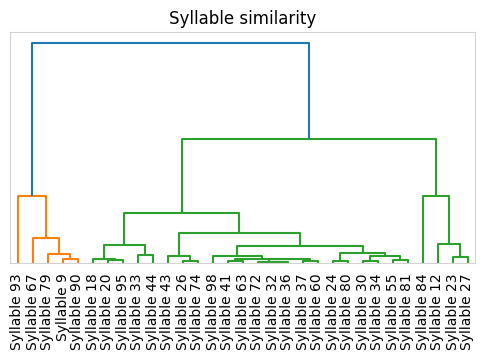

In [266]:

kpms.plot_similarity_dendrogram(coordinates, results, kpmoseq_dir, model_name, **config())

In [135]:

syllables_to_merge = [
    [38, 44, 81],
#    [33],
    [18,20,95]
]

# Generate a mapping that specifies how syllables will be relabled.
syllable_mapping = kpms.generate_syllable_mapping(results, syllables_to_merge)
results = kpms.apply_syllable_mapping(results, syllable_mapping)



In [221]:
rows = []
skipped = []

saline_mice = ["978513", "978527", "978528", "1079919"]
psilo_mice = [ "1010832", "1013590", "1034805", "1034814"]  # non-overlapping
psiloStim_mice = ["1079907", "1055495", "1075472", "1106648"]

for video in results.keys():

    m = re.match(r"mouse(\d+)_Day(\d+)", video)

    if m is None:
        skipped.append({"recording": video, "reason": "regex_no_match"})
        continue

    mouse = m.group(1)
    day = int(m.group(2))

    if mouse in Agg:
            group = "Agg"

    elif mouse in nonAgg:
            group = "nonAgg"

    elif mouse in maladaptive and day <= 5:
        group = "maladaptive baseline"

    elif mouse in psilo_mice and day >= 15:
        group = "maladaptive Psilocybin"
        
    elif mouse in psiloStim_mice and day >= 15:
            group = "maladaptive Psilocybin + Stim"

    elif mouse in saline_mice and day >= 15:
        group = "maladaptive Saline"
        
    else:
        skipped.append({
            "recording": video,
            "mouse": mouse,
            "day": day,
            "reason": "mouse_not_in_group_lists"
        })
        continue

    mouse_group_id = f"{mouse}_{group}"

    rows.append({
        "video": video,
        "mouse": mouse,                 # original animal ID
        "mouse_group_id": mouse_group_id, # analysis ID
        "day": day,
        "group": group
    })

resultsDataset = pd.DataFrame(rows)
skipped_df = pd.DataFrame(skipped)

In [222]:
all_syllables=[]

for rec in results:
    all_syllables.extend(
        results[rec]["syllable"]
    )

n_syll = len(np.unique(all_syllables))

In [289]:

# =============================================================
# SOURCES  --  point these at your own variables
# =============================================================
SYLL_RESULTS = results   # dict: video -> {"syllable": [...]}  (your syllable sequences)
META_DF      = resultsDataset     # DataFrame with a "video" column (+ "mouse", "group", ...)

# =============================================================
# SYLLABLE FILTER (label-blind) + FEATURE CONSTRUCTION
# =============================================================
# A syllable is kept only if it is used (> SYLL_MIN_USAGE fraction of frames)
# in at least SYLL_MIN_RECORDINGS recordings. Filtered syllables are dropped
# from BOTH the usage features and the transition matrix, so the n_syll^2
# transition block shrinks to kept^2 among present syllables.
SYLL_MIN_USAGE      = 0.00  # >0.5% of frames in a recording counts as "used"
SYLL_MIN_RECORDINGS = 0      # must be used in >= this many recordings

# renormalise kept-syllable frequencies to sum to 1 per recording
RENORM_USAGE = True

# transition semantics for filtered syllables:
#   False -> count only DIRECT kept->kept transitions (a filtered step breaks the chain)
#   True  -> drop filtered syllables from the sequence first, so i -> [filtered] -> j
#            is counted as a direct i -> j (bridges gaps)
BRIDGE_GAPS = False


def usage_freq(s, n):
    s = np.asarray(s)
    if len(s) == 0:
        return np.zeros(n)
    return np.bincount(s, minlength=n)[:n] / len(s)


def transition_counts(s, n):
    M = np.zeros((n, n))
    s = np.asarray(s)
    if len(s) > 1:
        np.add.at(M, (s[:-1], s[1:]), 1)
    return M


# recordings we actually have syllable sequences for
recs = list(SYLL_RESULTS.keys())

# IMPORTANT: array size must span the LARGEST syllable label + 1, NOT the count
# of distinct labels. Syllable IDs are non-contiguous (e.g. labels up to 90 but
# only 57 distinct), so len(np.unique(...)) undersizes the matrices and both
# crashes transition_counts and silently truncates usage_freq. Recompute here.
n_syll = 1 + max(
    int(np.asarray(SYLL_RESULTS[rec]["syllable"]).max())
    for rec in recs
    if len(np.asarray(SYLL_RESULTS[rec]["syllable"])) > 0
)
print(f"label span n_syll = {n_syll} (max label + 1)")

# ---- 1. decide which syllables survive the filter ----
freq_mat = np.vstack([usage_freq(SYLL_RESULTS[rec]["syllable"], n_syll) for rec in recs])
present  = (freq_mat > SYLL_MIN_USAGE).sum(axis=0)
kept     = np.where(present >= SYLL_MIN_RECORDINGS)[0]          # sorted original indices
print(f"kept {len(kept)} / {n_syll} syllables "
      f"-> {len(kept)} usage + {len(kept)**2} transition features")

# ---- 2. build syll_ + trans_ features on the kept syllables only ----
rows = []
for rec in recs:
    s = np.asarray(SYLL_RESULTS[rec]["syllable"])

    # usage over kept syllables (original indices preserved in the names)
    freq = usage_freq(s, n_syll)[kept]
    if RENORM_USAGE and freq.sum() > 0:
        freq = freq / freq.sum()

    # transitions among kept syllables
    if BRIDGE_GAPS:
        s_sub = s[np.isin(s, kept)]              # remove filtered syllables from the chain
        s_sub = np.searchsorted(kept, s_sub)     # remap originals -> 0..len(kept)-1
        C = transition_counts(s_sub, len(kept))
    else:
        C = transition_counts(s, n_syll)[np.ix_(kept, kept)]   # direct kept->kept only

    rowsum = C.sum(1, keepdims=True)
    P = np.divide(C, rowsum, where=rowsum > 0, out=np.zeros_like(C))

    row = {"video": rec}
    row.update({f"syll_{orig}": freq[k] for k, orig in enumerate(kept)})
    row.update({f"trans_{a}_{b}": P[ka, kb]
                for ka, a in enumerate(kept)
                for kb, b in enumerate(kept)})
    rows.append(row)

# attach metadata (mouse, group, ...); inner merge drops recordings without metadata
df = META_DF.merge(pd.DataFrame(rows).fillna(0), on="video", how="inner")
print("final df:", df.shape, "| mice:", df["mouse"].nunique())

label span n_syll = 100 (max label + 1)
kept 100 / 100 syllables -> 100 usage + 10000 transition features
final df: (283, 10105) | mice: 32


In [290]:
mouse_df = (
    df.groupby(["mouse_group_id", "group"])
    .mean(numeric_only=True)
    .reset_index()
)

In [297]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# =============================================================
# HYPERPARAMETERS
# =============================================================
# "none" | "variance" | "dispersion" | "laplacian" | "mutual_info"
FEATURE_SELECTION_METHOD = "variance"

# fraction of valid features to keep (ignored when method == "none")
FEATURE_FRACTION = 0.75
LAPLACIAN_K = 3
RANDOM_STATE = 42

# which feature blocks to feed the pipeline: syllable usage and/or transitions
FEATURE_REGEX = r"^(syll|trans)_"

# -----------------------------
# settings
# -----------------------------
group_colors = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
group_markers = {"nonAgg": "o", "Agg": "s", "maladaptive": "^"}
group_order = ["nonAgg", "Agg", "maladaptive"]

pc_cmap = LinearSegmentedColormap.from_list(
    "blue_orange_red", ["#5AA2E6", "#E6A55A", "#E65A5A"])

# -----------------------------
# keep nonAgg, Agg, and maladaptive BASELINE only
# (after-Saline / after-Psilocybin are repeat recordings of the same mice
#  -> excluded to avoid pseudoreplication; they are NOT merged in)
# -----------------------------
plot_df = mouse_df.copy()
plot_df = plot_df[plot_df["group"].isin(["nonAgg", "Agg", "maladaptive baseline"])].copy()
plot_df["group_merged"] = plot_df["group"].replace({"maladaptive baseline": "maladaptive"})
print(plot_df["group_merged"].value_counts().to_string())

# -----------------------------
# features  (syllables + transitions)
# -----------------------------
X_df = plot_df.filter(regex=FEATURE_REGEX).copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# no floor (you found the algorithm works better without it)
min_recordings = 1
presence = (X_df > 0).sum(axis=0)
valid_features = presence[presence >= min_recordings].index
X_df = X_df[valid_features]

X_log = np.log(X_df + 1e-8)

top_n = max(1, int(len(valid_features) * FEATURE_FRACTION))

y = LabelEncoder().fit_transform(plot_df["group_merged"])


# =============================================================
# feature-selection dispatch
# =============================================================
def select_features(method, X_df, X_log, y, top_n, k=5, random_state=42):
    """Return an Index of selected feature names according to `method`."""
    if method == "none":
        return X_df.columns

    if method == "variance":
        scores = X_log.var(axis=0)
        return scores.sort_values(ascending=False).head(top_n).index

    if method == "dispersion":
        mean = X_df.mean(axis=0)
        std = X_df.std(axis=0)
        scores = std / mean.replace(0, np.nan)
        scores = scores.replace([np.inf, -np.inf], np.nan).fillna(0)
        return scores.sort_values(ascending=False).head(top_n).index

    if method == "laplacian":
        try:
            from skfeature.function.similarity_based import lap_score
            from skfeature.utility.construct_W import construct_W
        except ImportError as e:
            raise ImportError(
                "The 'laplacian' method needs skfeature. Install it with:\n"
                "    pip install skfeature-chappers"
            ) from e
        X_all = StandardScaler().fit_transform(X_log)
        W = construct_W(X_all, metric="euclidean", neighbor_mode="knn",
                        weight_mode="heat_kernel", k=k, t=1)
        scores = lap_score.lap_score(X_all, W=W)   # lower score = better
        ranks = np.argsort(scores)
        return X_df.columns[ranks[:top_n]]

    if method == "mutual_info":
        # SUPERVISED -- uses group labels, circular. Kept only for comparison.
        X_scaled = StandardScaler().fit_transform(X_log)
        mi = mutual_info_classif(X_scaled, y, random_state=random_state)
        scores = pd.Series(mi, index=X_df.columns).sort_values(ascending=False)
        return scores.head(top_n).index

    raise ValueError(
        f"Unknown FEATURE_SELECTION_METHOD={method!r}. "
        "Choose one of: 'none', 'variance', 'dispersion', 'laplacian', 'mutual_info'."
    )


top_features = select_features(
    FEATURE_SELECTION_METHOD, X_df, X_log, y, top_n,
    k=LAPLACIAN_K, random_state=RANDOM_STATE,
)

# how many of the selected features are usage vs transitions (sanity check)
n_syll_sel = sum(str(f).startswith("syll_") for f in top_features)
n_trans_sel = sum(str(f).startswith("trans_") for f in top_features)
print(f"[feature selection] method = {FEATURE_SELECTION_METHOD}")
print(f"[feature selection] kept {len(top_features)} / {len(valid_features)} features "
      f"({n_syll_sel} usage, {n_trans_sel} transitions)")

# -----------------------------
# PCA
# -----------------------------
X_selected = X_log[top_features]
X_selected_scaled = StandardScaler().fit_transform(X_selected)

pca = PCA(n_components=2)
Y = pca.fit_transform(X_selected_scaled)

plot_df["PC1"] = Y[:, 0]
plot_df["PC2"] = Y[:, 1]

# -----------------------------
# PC1 loadings
# -----------------------------
pc1_weights = pd.Series(pca.components_[0], index=top_features, name="PC1_weight")

top_loadings = (
    pc1_weights
    .reindex(pc1_weights.abs().sort_values(ascending=False).head(20).index)
    .sort_values()
)

# -----------------------------
# PC1 distribution data
# -----------------------------
violin_data = [
    plot_df.loc[plot_df["group_merged"] == g, "PC1"].values
    for g in group_order
]

# -----------------------------
# per-group feature contribution to PC1
# -----------------------------
X_selected_df = pd.DataFrame(X_selected_scaled, columns=top_features, index=plot_df.index)

pc1_contrib = X_selected_df.mul(pc1_weights, axis=1)
pc1_contrib["group"] = plot_df["group_merged"].values

group_pc1_contrib = pc1_contrib.groupby("group").mean().T

# cap the heatmap: with transitions top_n can be huge, so show the 30 strongest
top_heat_n = min(top_n, 30)

top_syllables = (
    group_pc1_contrib.abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .head(top_heat_n)
    .index
)

heat = group_pc1_contrib.loc[top_syllables, group_order]

max_abs = max(np.abs(top_loadings.values).max(), np.abs(heat.values).max())

norm = Normalize(vmin=-max_abs, vmax=max_abs)
sm = ScalarMappable(norm=norm, cmap=pc_cmap)
sm.set_array([])

group_merged
maladaptive    12
Agg            11
nonAgg          9
[feature selection] method = variance
[feature selection] kept 1298 / 1731 features (39 usage, 1259 transitions)


[sign] PC1 already oriented with 'maladaptive' highest


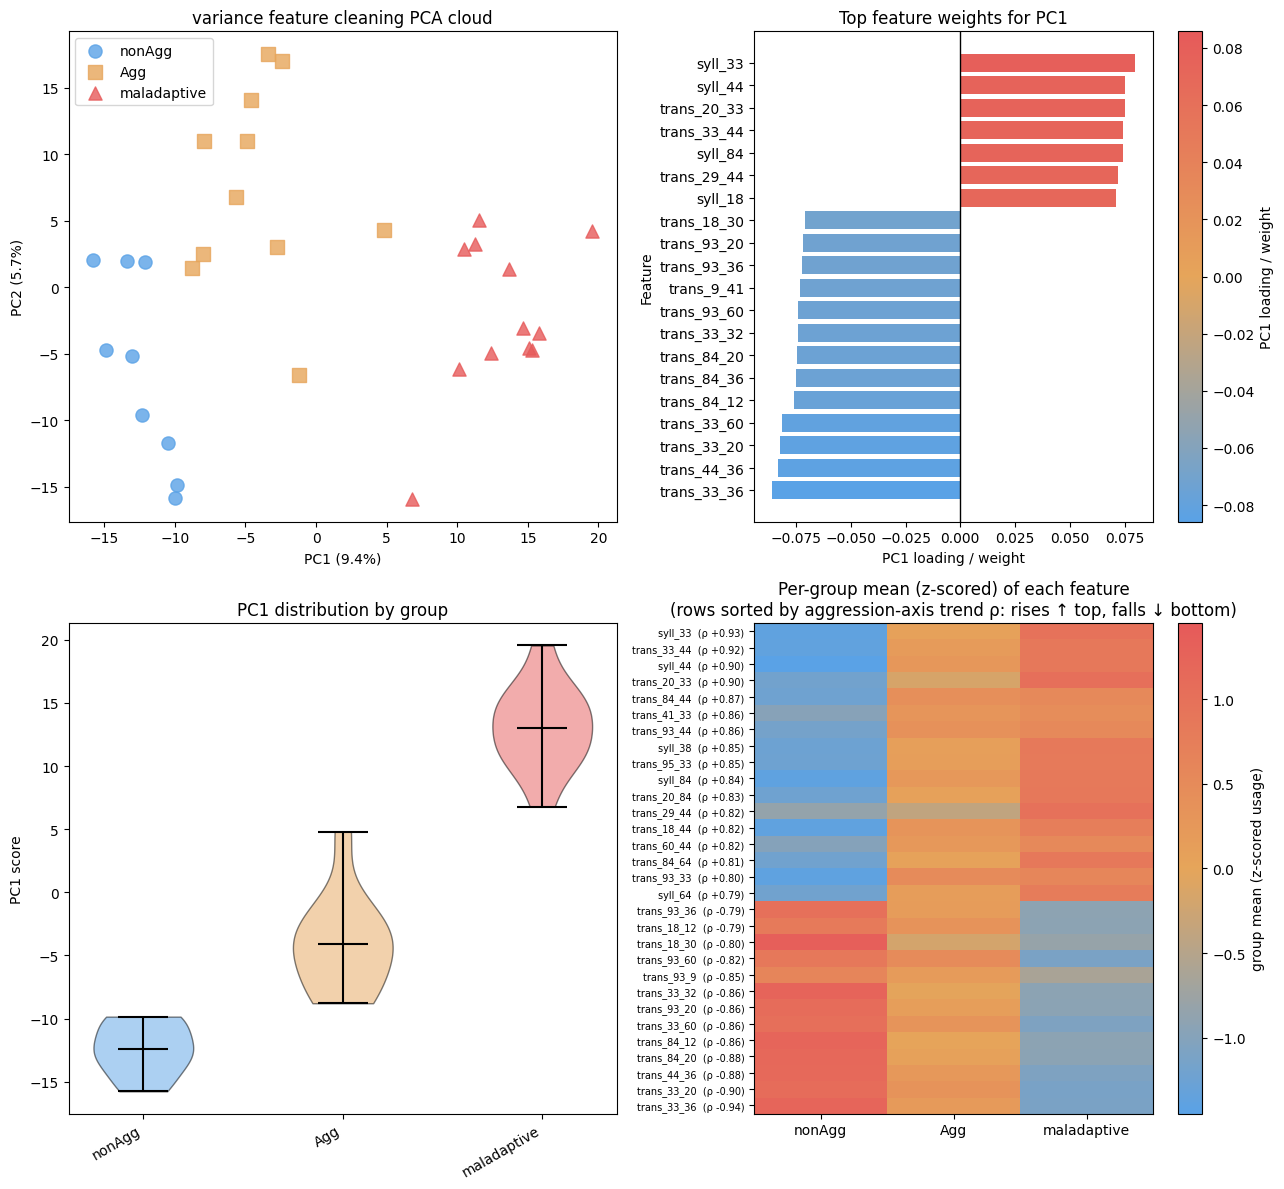

In [301]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.stats import spearmanr

# =============================================================
# 0. sign convention -- flip PC1 so SIGN_ANCHOR_GROUP scores highest,
#    then RECOMPUTE every sign-dependent quantity so all 4 panels agree.
#    (idempotent: if it's already oriented, nothing flips.)
# =============================================================
SIGN_ANCHOR_GROUP = "maladaptive"

if plot_df.groupby("group_merged")["PC1"].mean().idxmax() != SIGN_ANCHOR_GROUP:
    plot_df["PC1"] = -plot_df["PC1"]
    pca.components_[0] = -pca.components_[0]
    print(f"[sign] flipped PC1 so '{SIGN_ANCHOR_GROUP}' scores highest")
else:
    print(f"[sign] PC1 already oriented with '{SIGN_ANCHOR_GROUP}' highest")

# --- recompute loadings / violins from the (possibly flipped) sign ---
pc1_weights = pd.Series(pca.components_[0], index=top_features, name="PC1_weight")

top_loadings = (
    pc1_weights
    .reindex(pc1_weights.abs().sort_values(ascending=False).head(20).index)
    .sort_values()
)

violin_data = [
    plot_df.loc[plot_df["group_merged"] == g, "PC1"].values
    for g in group_order
]

X_selected_df = pd.DataFrame(X_selected_scaled, columns=top_features, index=plot_df.index)

# =============================================================
# rank features by SIGNED, MONOTONIC trend along the ordered aggression axis
# (nonAgg=0, Agg=1, maladaptive=2).  Spearman rho in [-1, 1]:
#   rho > 0  -> feature RISES with aggression   (blue -> red across the row)
#   rho < 0  -> feature FALLS with aggression   (red -> blue across the row)
# This replaces the direction-agnostic pairwise AUC, which lumped rising,
# falling, and Agg-peaked features together and made the panel look scrambled.
# =============================================================
labels_arr = plot_df["group_merged"].values
group_rank = {g: i for i, g in enumerate(group_order)}          # nonAgg<Agg<maladaptive
ord_code   = np.array([group_rank[g] for g in labels_arr])

trend = pd.Series(
    {f: spearmanr(X_selected_df[f].values, ord_code).correlation for f in top_features},
    name="trend",
)

# =============================================================
# HEATMAP DATA: per-group MEAN of the standardized feature value (z units).
# Rows = strongest |trend| features, DISPLAYED sorted by signed trend so the map
# reads top (rises with aggression) -> bottom (falls with aggression).
# =============================================================
group_z = X_selected_df.copy()
group_z["group"] = labels_arr
group_z = group_z.groupby("group").mean().T                      # features x groups, z units

top_heat_n = min(30, len(top_features))
strongest  = trend.abs().sort_values(ascending=False).head(top_heat_n).index
top_features_ranked = trend.loc[strongest].sort_values(ascending=False).index   # signed order

heat = group_z.loc[top_features_ranked, group_order]
heat.index = [f"{f}  (ρ {trend[f]:+.2f})" for f in top_features_ranked]

# --- independent colour scales: loadings (panel 2) and group-z heatmap (panel 4) ---
lmax = np.abs(top_loadings.values).max()
norm_l = Normalize(vmin=-lmax, vmax=lmax)
sm_l = ScalarMappable(norm=norm_l, cmap=pc_cmap); sm_l.set_array([])

zmax = np.abs(heat.values).max()
norm_h = Normalize(vmin=-zmax, vmax=zmax)
sm_h = ScalarMappable(norm=norm_h, cmap=pc_cmap); sm_h.set_array([])

# =============================================================
# figure
# =============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 12), gridspec_kw={"width_ratios": [1.1, 1]})

# -----------------------------
# 1. PCA cloud
# -----------------------------
ax = axes[0, 0]
for g in group_order:
    idx = plot_df["group_merged"] == g
    ax.scatter(plot_df.loc[idx, "PC1"], plot_df.loc[idx, "PC2"],
               label=g, color=group_colors[g], marker=group_markers[g], alpha=0.8, s=90)
ax.legend(loc="upper left")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title(f"{FEATURE_SELECTION_METHOD} feature cleaning PCA cloud")

# -----------------------------
# 2. Top PC1 feature weights
# -----------------------------
ax = axes[0, 1]
ax.barh(top_loadings.index, top_loadings.values, color=[pc_cmap(norm_l(v)) for v in top_loadings.values])
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("PC1 loading / weight")
ax.set_ylabel("Feature")
ax.set_title("Top feature weights for PC1")
fig.colorbar(sm_l, ax=ax).set_label("PC1 loading / weight")

# -----------------------------
# 3. PC1 violin plot by group
# -----------------------------
ax = axes[1, 0]
vp = ax.violinplot(violin_data, showmeans=True, showmedians=False)
for body, g in zip(vp["bodies"], group_order):
    body.set_facecolor(group_colors[g]); body.set_edgecolor("black"); body.set_alpha(0.5)
for key in ["cmeans", "cbars", "cmins", "cmaxes"]:
    vp[key].set_color("black")
ax.set_xticks(np.arange(1, len(group_order) + 1))
ax.set_xticklabels(group_order, rotation=30, ha="right")
ax.set_ylabel("PC1 score")
ax.set_title("PC1 distribution by group")

# -----------------------------
# 4. Per-group mean (z-scored) of each feature, rows ranked by inter-class AUC
# -----------------------------
ax = axes[1, 1]
im = ax.imshow(heat, aspect="auto", cmap=pc_cmap, norm=norm_h)
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=7)
ax.set_title("Per-group mean (z-scored) of each feature\n(rows sorted by aggression-axis trend ρ: rises ↑ top, falls ↓ bottom)")
fig.colorbar(sm_h, ax=ax).set_label("group mean (z-scored usage)")

plt.tight_layout()
plt.savefig("pc1_panels_auc_ranked.png", dpi=200, bbox_inches="tight")
plt.show()

In [302]:
import numpy as np
row = [c for c in df.columns if c.startswith("trans_33_")]
print(df[row].sum(axis=1).describe())   # ~1.0 per recording => conditional P(j|33); else joint counts

count    2.830000e+02
mean     1.000000e+00
std      1.467943e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64


In [299]:
jjjjjjj

NameError: name 'jjjjjjj' is not defined

In [ ]:
# =============================================================
# Highest / lowest PC1 mouse in each group
# =============================================================

MOUSE_COL = "mouse_group_id"   # change this if your column has another name

pc1_extremes = []

for g in group_order:
    sub = plot_df.loc[plot_df["group_merged"] == g]

    idx_high = sub["PC1"].idxmax()
    idx_low = sub["PC1"].idxmin()

    pc1_extremes.append({
        "group": g,
        "highest_mouse": plot_df.loc[idx_high, MOUSE_COL],
        "highest_PC1": plot_df.loc[idx_high, "PC1"],
        "lowest_mouse": plot_df.loc[idx_low, MOUSE_COL],
        "lowest_PC1": plot_df.loc[idx_low, "PC1"],
    })

pc1_extremes_df = pd.DataFrame(pc1_extremes)

print(pc1_extremes_df.to_string(index=False))

      group                highest_mouse  highest_PC1                 lowest_mouse  lowest_PC1
     nonAgg                975830_nonAgg    -9.848817               1010819_nonAgg  -15.755956
        Agg                  1029741_Agg     4.807022                   988590_Agg   -8.782582
maladaptive 1079907_maladaptive baseline    19.545546 1055495_maladaptive baseline    6.771692


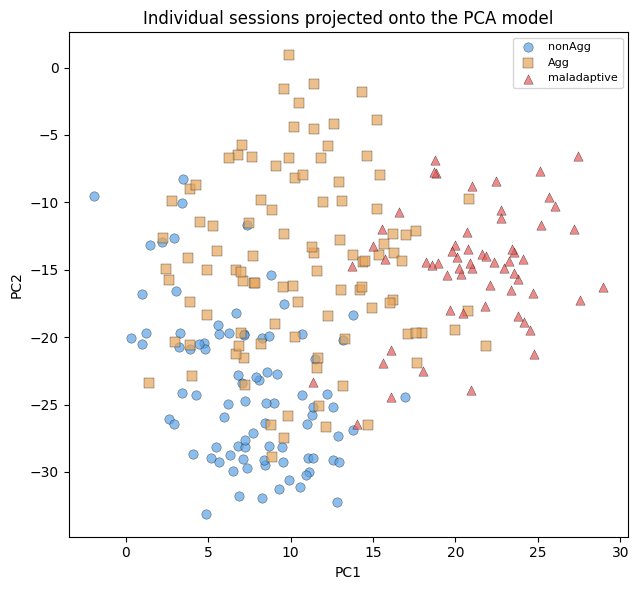

In [303]:
# project individual sessions onto the already-fitted PCA (reuses pca, top_features, X_log)
scaler = StandardScaler().fit(X_log[top_features])            # same transform PCA was trained on

# keep nonAgg, Agg, maladaptive BASELINE only (exclude after-Saline / after-Psilocybin sessions)
sess = df[df["group"].isin(["nonAgg", "Agg", "maladaptive baseline"])].copy()
sess["group_merged"] = sess["group"].replace({"maladaptive baseline": "maladaptive"})

feat = sess.reindex(columns=top_features).replace([np.inf, -np.inf], np.nan).fillna(0)
proj = pca.transform(scaler.transform(np.log(feat + 1e-8)))   # sign already matches the flipped axis
sess["PC1"], sess["PC2"] = proj[:, 0], proj[:, 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
for g in group_order:
    sub = sess[sess["group_merged"] == g]
    ax.scatter(sub["PC1"], sub["PC2"], s=45, alpha=0.7, label=g,
               color=group_colors[g], marker=group_markers[g], edgecolor="black", linewidth=0.3)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Individual sessions projected onto the PCA model")
ax.legend(loc="best", fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
cols = [c for c in ["video", "mouse_group_id", "day", "group", "PC1"] if c in sess.columns]
N = 10   # how many extremes to show per end

for g in group_order:
    sub = sess[sess["group_merged"] == g].sort_values("PC1")
    print(f"\n===== {g}  (n = {len(sub)}) =====")
    print("--- lowest PC1 ---")
    print(sub[cols].head(N).to_string(index=False))
    print("--- highest PC1 ---")
    print(sub[cols].tail(N)[::-1].to_string(index=False))


===== nonAgg  (n = 87) =====
--- lowest PC1 ---
             video mouse_group_id  day  group       PC1
mouse1010819_Day06 1010819_nonAgg    6 nonAgg -1.911164
 mouse997839_Day06  997839_nonAgg    6 nonAgg  0.345408
 mouse997841_Day06  997841_nonAgg    6 nonAgg  1.002804
 mouse978775_Day02  978775_nonAgg    2 nonAgg  1.024929
mouse1010819_Day10 1010819_nonAgg   10 nonAgg  1.233594
mouse1010819_Day08 1010819_nonAgg    8 nonAgg  1.488164
 mouse997841_Day03  997841_nonAgg    3 nonAgg  2.240596
mouse1010819_Day07 1010819_nonAgg    7 nonAgg  2.615434
 mouse975830_Day17  975830_nonAgg   17 nonAgg  2.918494
 mouse978775_Day10  978775_nonAgg   10 nonAgg  2.944127
--- highest PC1 ---
             video mouse_group_id  day  group       PC1
mouse1029736_Day05 1029736_nonAgg    5 nonAgg 16.918367
 mouse997840_Day08  997840_nonAgg    8 nonAgg 13.808250
mouse1029739_Day06 1029739_nonAgg    6 nonAgg 13.803683
mouse1032216_Day04 1032216_nonAgg    4 nonAgg 13.189934
 mouse975830_Day05  975830_nonAgg  

treat              phase 
Psilocybin         after     4
                   before    4
Psilocybin + Stim  after     1
                   before    1
Saline             after     4
                   before    4


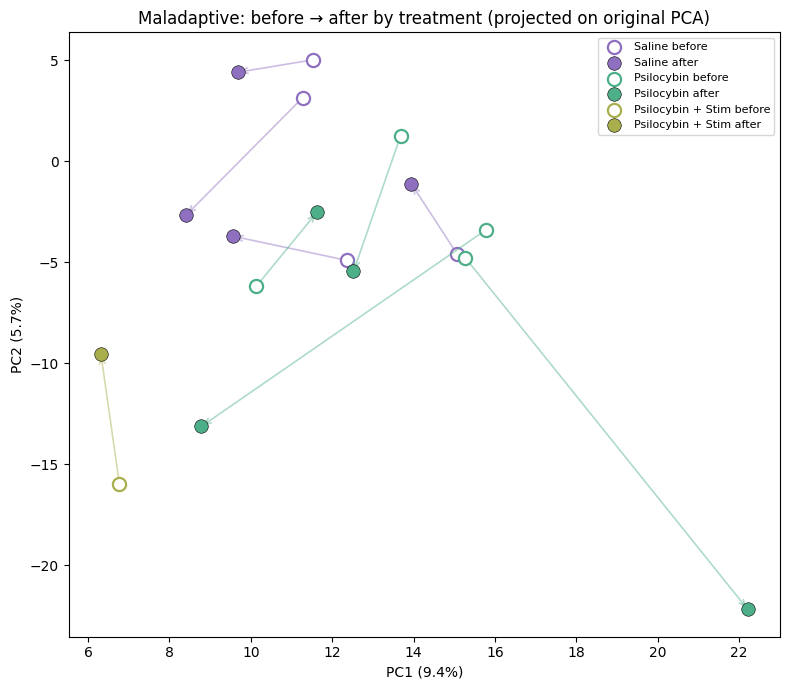

In [ ]:
# =============================================================
# Maladaptive only: pair each mouse's BEFORE (week-1 baseline) with its
# AFTER (week-2 treatment), split by treatment, projected on PC1/PC2.
# Requires from the model cell: pca, top_features, X_log
# =============================================================
TREAT = {"maladaptive Saline": "Saline",
         "maladaptive Psilocybin": "Psilocybin",
         "maladaptive Psilocybin + Stim": "Psilocybin + Stim"}
TREAT_ORDER = ["Saline", "Psilocybin", "Psilocybin + Stim"]
tcol = {"Saline": "#8E6FC0", "Psilocybin": "#4CAF88", "Psilocybin + Stim": "#A8AF4C"}

mal = mouse_df[mouse_df["group"].astype(str).str.startswith("maladaptive")].copy()

# bare animal ID from mouse_group_id ("978513_maladaptive Saline" -> "978513")
if "mouse" not in mal.columns:
    mal["mouse"] = mal["mouse_group_id"].astype(str).str.split("_", n=1).str[0]

# treatment per mouse = the after-group it appears in
after = mal[mal["group"].isin(TREAT)]
mouse_treat = dict(zip(after["mouse"], after["group"].map(TREAT)))

def _label(row):
    if row["group"] == "maladaptive baseline":
        t = mouse_treat.get(row["mouse"]);  return (t, "before") if t else (None, None)
    t = TREAT.get(row["group"]);            return (t, "after") if t else (None, None)

mal[["treat", "phase"]] = mal.apply(lambda r: pd.Series(_label(r)), axis=1)
mal = mal.dropna(subset=["treat"]).copy()

# ---- project onto the fitted PCA ----
scaler = StandardScaler().fit(X_log[top_features])
Z = scaler.transform(np.log(mal.reindex(columns=top_features)
                            .replace([np.inf, -np.inf], np.nan).fillna(0) + 1e-8))
P = pca.transform(Z)
mal["PC1"], mal["PC2"] = P[:, 0], P[:, 1]

print(mal.groupby(["treat", "phase"]).size().to_string())

# ---- figure ----
fig, ax = plt.subplots(figsize=(8, 7))
for t in TREAT_ORDER:
    sub = mal[mal["treat"] == t]
    for mouse, g in sub.groupby("mouse"):                       # before -> after arrow per mouse
        b = g[g["phase"] == "before"]; a = g[g["phase"] == "after"]
        if len(b) and len(a):
            ax.annotate("", xy=(a["PC1"].iloc[0], a["PC2"].iloc[0]),
                        xytext=(b["PC1"].iloc[0], b["PC2"].iloc[0]),
                        arrowprops=dict(arrowstyle="->", color=tcol[t], alpha=0.45, lw=1.2))
    bf = sub[sub["phase"] == "before"]; af = sub[sub["phase"] == "after"]
    ax.scatter(bf["PC1"], bf["PC2"], facecolor="white", edgecolor=tcol[t],
               marker="o", s=90, linewidth=1.6, label=f"{t} before", zorder=3)
    ax.scatter(af["PC1"], af["PC2"], facecolor=tcol[t], edgecolor="black",
               marker="o", s=95, linewidth=0.4, label=f"{t} after", zorder=3)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Maladaptive: before → after by treatment (projected on original PCA)")
ax.legend(loc="best", fontsize=8)
plt.tight_layout(); plt.show()

treat              phase 
Psilocybin         after     4
                   before    4
Psilocybin + Stim  after     1
                   before    1
Saline             after     4
                   before    4


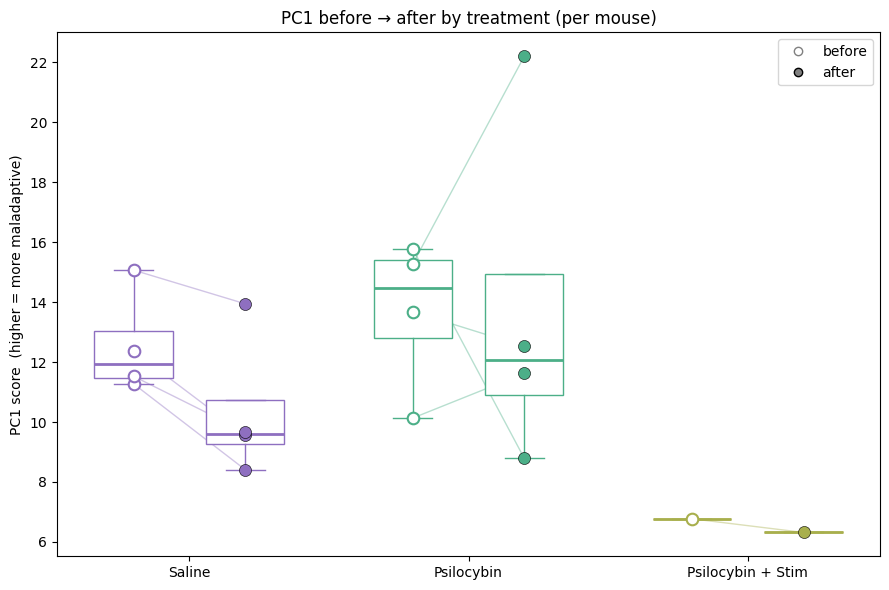

In [ ]:
# =============================================================
# PC1 before vs after by treatment, one point per mouse (paired).
# Requires from the model cell: pca, top_features, X_log
# =============================================================
TREAT = {"maladaptive Saline": "Saline",
         "maladaptive Psilocybin": "Psilocybin",
         "maladaptive Psilocybin + Stim": "Psilocybin + Stim"}
TREAT_ORDER = ["Saline", "Psilocybin", "Psilocybin + Stim"]
tcol = {"Saline": "#8E6FC0", "Psilocybin": "#4CAF88", "Psilocybin + Stim": "#A8AF4C"}

mal = mouse_df[mouse_df["group"].astype(str).str.startswith("maladaptive")].copy()
if "mouse" not in mal.columns:
    mal["mouse"] = mal["mouse_group_id"].astype(str).str.split("_", n=1).str[0]
after = mal[mal["group"].isin(TREAT)]
mouse_treat = dict(zip(after["mouse"], after["group"].map(TREAT)))

def _label(row):
    if row["group"] == "maladaptive baseline":
        t = mouse_treat.get(row["mouse"]);  return (t, "before") if t else (None, None)
    t = TREAT.get(row["group"]);            return (t, "after") if t else (None, None)

mal[["treat", "phase"]] = mal.apply(lambda r: pd.Series(_label(r)), axis=1)
mal = mal.dropna(subset=["treat"]).copy()

scaler = StandardScaler().fit(X_log[top_features])
Z = scaler.transform(np.log(mal.reindex(columns=top_features)
                            .replace([np.inf, -np.inf], np.nan).fillna(0) + 1e-8))
mal["PC1"] = pca.transform(Z)[:, 0]
print(mal.groupby(["treat", "phase"]).size().to_string())

# ---- figure ----
fig, ax = plt.subplots(figsize=(9, 6))
DX = 0.2
for ti, t in enumerate(TREAT_ORDER):
    xb, xa = ti - DX, ti + DX
    sub = mal[mal["treat"] == t]
    bvals = sub[sub["phase"] == "before"]["PC1"].values
    avals = sub[sub["phase"] == "after"]["PC1"].values
    # boxes
    ax.boxplot([bvals, avals], positions=[xb, xa], widths=0.28, patch_artist=True,
               manage_ticks=False, showfliers=False,
               boxprops=dict(facecolor="white", edgecolor=tcol[t]),
               medianprops=dict(color=tcol[t], lw=2),
               whiskerprops=dict(color=tcol[t]), capprops=dict(color=tcol[t]))
    # paired lines per mouse
    for mouse, g in sub.groupby("mouse"):
        b = g[g["phase"] == "before"]["PC1"]; a = g[g["phase"] == "after"]["PC1"]
        if len(b) and len(a):
            ax.plot([xb, xa], [b.iloc[0], a.iloc[0]], color=tcol[t], alpha=0.4, lw=1, zorder=1)
    # points: before hollow, after filled
    ax.scatter(np.full(len(bvals), xb), bvals, facecolor="white", edgecolor=tcol[t],
               s=70, linewidth=1.5, zorder=3)
    ax.scatter(np.full(len(avals), xa), avals, facecolor=tcol[t], edgecolor="black",
               s=75, linewidth=0.4, zorder=3)

ax.set_xticks(range(len(TREAT_ORDER))); ax.set_xticklabels(TREAT_ORDER)
ax.set_ylabel("PC1 score  (higher = more maladaptive)")
ax.set_title("PC1 before → after by treatment (per mouse)")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0], [0], marker="o", ls="none", mfc="white", mec="gray", label="before"),
                   Line2D([0], [0], marker="o", ls="none", mfc="gray", mec="black", label="after")],
          loc="best")
plt.tight_layout(); plt.show()

In [306]:
import os
import re
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ANNOT_DIR  = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\fig1_trainingSessions_annotationsNoemie_non_agg_mal")
BEHAVIOR   = "attackOfInt"
TARGET_FPS = 50.0
DO_PERM    = True

# Boolean column in resultsDataset that flags the MR (resident) sessions.
# Set to None to use every row.
MR_COLUMN  = "MR"

# --- syllable count from the FULL model, not the annotated subset ---
n_syll = max(int(np.asarray(results[k]["syllable"]).max()) for k in results) + 1

# --- (mouse, day) -> video key, straight from resultsDataset (MR only) ---
_meta = resultsDataset

_meta = _meta.copy()
_meta["mouse"] = _meta["mouse"].astype(str)
_meta["day"]   = _meta["day"].astype(int)
mr_lut = _meta.drop_duplicates(["mouse", "day"]).set_index(["mouse", "day"])["video"]

print(f"mr_lut: {len(mr_lut)} (mouse,day) entries after MR filter")
print(f"  sample mr_lut keys : {list(mr_lut.index[:6])}")


def parse_annot(path, behavior):
    fps, intervals, grab = None, [], False
    for ln in open(path, encoding="utf-8", errors="ignore").read().splitlines():
        s = ln.strip()
        if s.lower().startswith("annotation framerate"):
            fps = float(s.split(":")[1]); continue
        if s.startswith(">"):
            grab = (s[1:].strip() == behavior); continue
        if grab:
            p = s.split()
            if len(p) == 3 and p[0].lstrip("-").isdigit():
                intervals.append((int(p[0]), int(p[1])))
    return fps, intervals


# --- pool syllables + attack mask across annotated MR sessions ---
all_syll, all_att, matched = [], [], []
skips = Counter()
parsed_sample, files = [], sorted(ANNOT_DIR.rglob("*.annot"))

for path in files:
    m = re.search(r"m(?:ouse)?(\d+)_Day(\d+)", os.path.basename(path), re.IGNORECASE)
    if not m:
        skips["no_id_in_filename"] += 1
        continue
    mouse, day = str(m.group(1)), int(m.group(2))
    if len(parsed_sample) < 6:
        parsed_sample.append((mouse, day))
    if (mouse, day) not in mr_lut.index:
        skips["not_in_mr_lut"] += 1
        continue
    fps, iv = parse_annot(path, BEHAVIOR)
    if fps is None:
        skips["no_framerate"] += 1
        continue
    key = mr_lut.loc[(mouse, day)]
    if key not in results:
        skips["key_not_in_results"] += 1
        continue
    syll = np.asarray(results[key]["syllable"])
    step = max(1, int(round(fps / TARGET_FPS)))
    a = np.zeros(len(syll), bool)
    for start, stop in iv:
        lo, hi = (start - 1) // step, (stop - 1) // step
        a[max(0, lo):min(len(a), hi + 1)] = True
    all_syll.append(syll); all_att.append(a); matched.append(key)

print(f"\n.annot files found : {len(files)}")
print(f"matched sessions   : {len(matched)}")
print(f"skips              : {dict(skips)}")
print(f"  sample parsed keys : {parsed_sample}")

if not matched:
    raise RuntimeError(
        "No sessions matched -- nothing to concatenate.\n"
        "Compare 'sample mr_lut keys' with 'sample parsed keys' above:\n"
        "  * if the mouse strings differ (e.g. '1010819' vs 'mouse1010819'), fix the regex or the cast\n"
        "  * if days differ (2 vs 'Day02'), fix the day dtype\n"
        "  * if mr_lut is empty, MR_COLUMN filtered out every row (wrong column / all False)\n"
        "  * if skips are all 'no_id_in_filename', the filenames don't contain m<digits>_Day<digits>"
    )

S = np.concatenate(all_syll); A = np.concatenate(all_att); base = A.mean()
print(f"\nmatched {len(matched)} sessions | {len(S)} frames | n_syll={n_syll} | attack rate={base:.3f}")

# --- per-syllable enrichment + point-biserial correlation (over the FULL syllable space) ---
OH = np.stack([(S == k) for k in range(n_syll)], 1).astype(float)
O0 = OH - OH.mean(0); O0n = np.sqrt((O0 ** 2).sum(0))
corr_all = lambda a: (O0 * (a - a.mean())[:, None]).sum(0) / (O0n * np.sqrt(((a - a.mean()) ** 2).sum()) + 1e-12)
obs = corr_all(A.astype(float))

nfr = OH.sum(0).astype(int)
tab = pd.DataFrame({"syllable": range(n_syll), "n_frames": nfr,
                    "P_attack_given_syll": [A[S == k].mean() if (S == k).any() else np.nan for k in range(n_syll)]})
tab["log2_enrich"] = np.log2((tab["P_attack_given_syll"] + 1e-9) / (base + 1e-9))
tab["corr_r"] = np.where(nfr > 0, obs, np.nan)

if DO_PERM:
    rng = np.random.default_rng(0); n_perm = 500
    null = np.array([corr_all(np.concatenate([np.roll(a, int(rng.integers(1, len(a)))) for a in all_att]).astype(float))
                     for _ in range(n_perm)])
    tab["p_perm"] = np.where(nfr > 0, (np.sum(np.abs(null) >= np.abs(obs), 0) + 1) / (n_perm + 1), np.nan)

tab = tab.sort_values("corr_r", ascending=False)
print(tab.round(4).to_string(index=False))

t = tab.sort_values("syllable")
sig = (t["p_perm"] < 0.05) if DO_PERM else t["corr_r"].abs().gt(0)

mr_lut: 283 (mouse,day) entries after MR filter
  sample mr_lut keys : [('1010819', 2), ('1010819', 4), ('1010819', 5), ('1010819', 6), ('1010819', 7), ('1010819', 8)]

.annot files found : 45
matched sessions   : 43
skips              : {'no_id_in_filename': 2}
  sample parsed keys : [('1010820', 2), ('1010820', 6), ('1010820', 12), ('1010823', 2), ('1010823', 6), ('1010823', 11)]

matched 43 sessions | 2689573 frames | n_syll=100 | attack rate=0.032
 syllable  n_frames  P_attack_given_syll  log2_enrich  corr_r  p_perm
       33     40395               0.6146       4.2418  0.4055  0.0020
       44     15853               0.8326       4.6798  0.3475  0.0020
       84     22360               0.4632       3.8337  0.2224  0.0020
       93     20270               0.4574       3.8157  0.2089  0.0020
       18     51161               0.2557       2.9765  0.1753  0.0020
       38      2026               0.7833       4.5917  0.1163  0.0020
       64      1139               0.7673       4.5620 

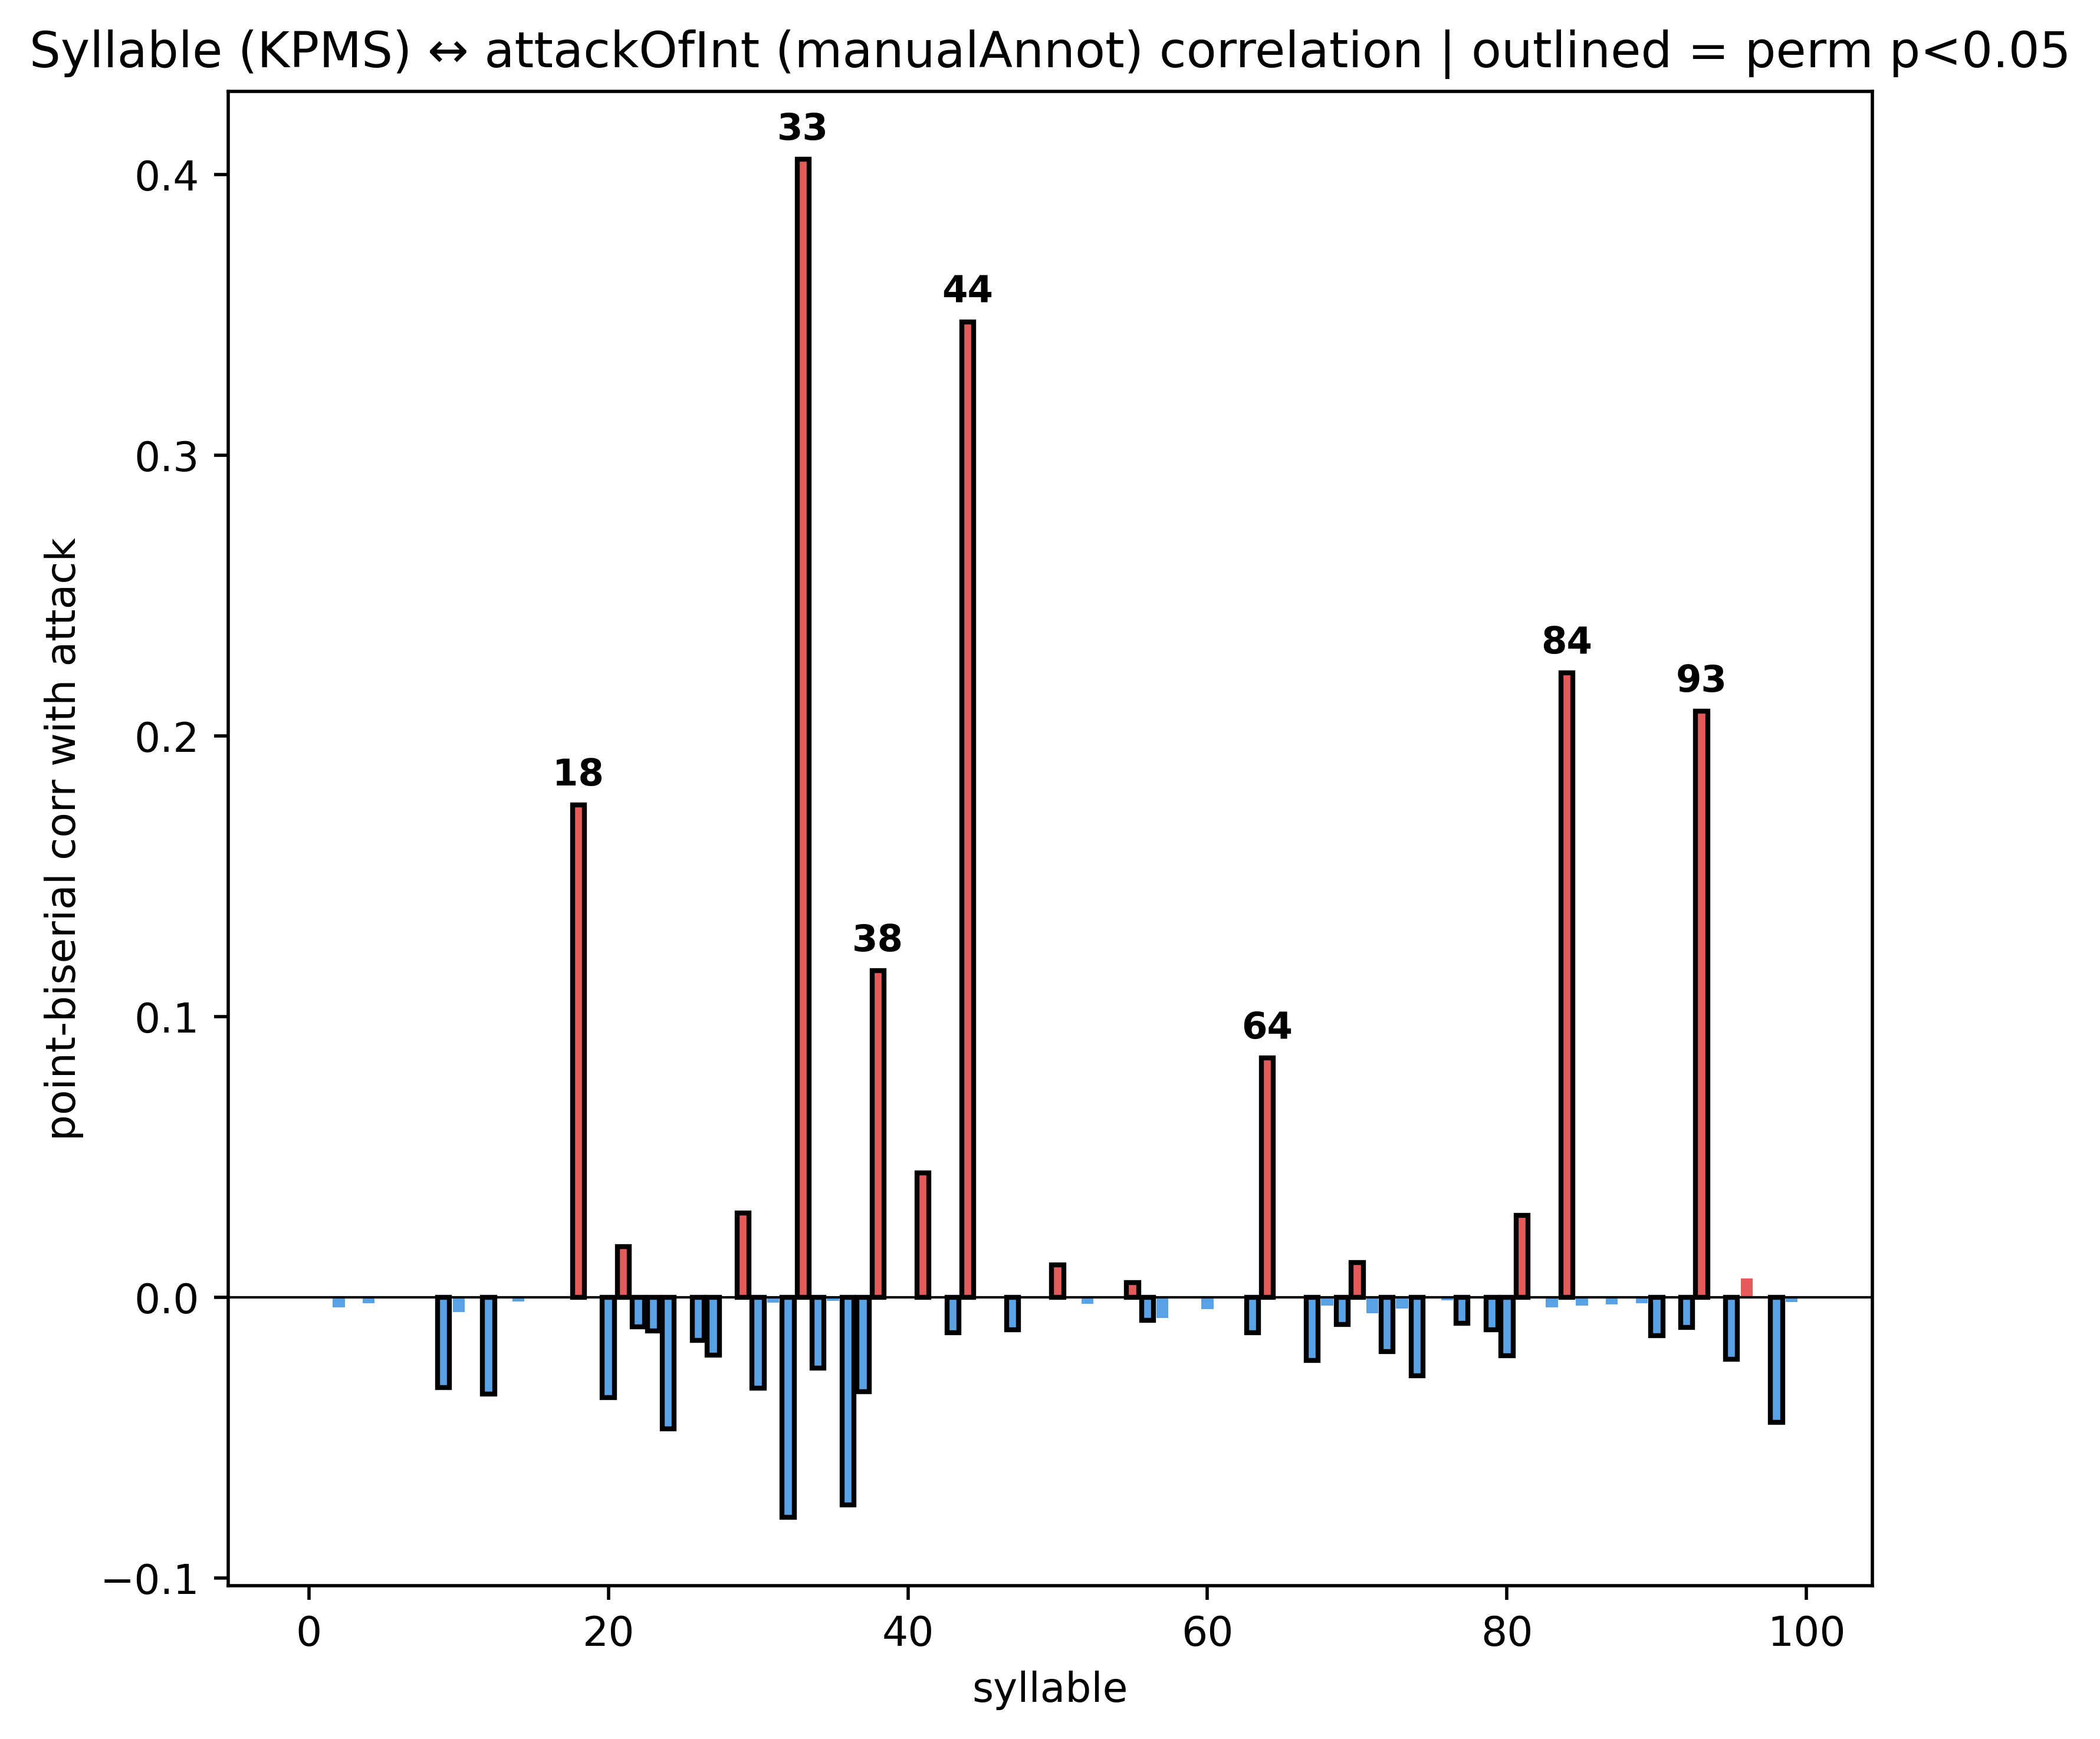

In [307]:
fig, ax = plt.subplots(figsize=(6.5, 6), dpi=500)
ax.bar(t["syllable"], t["corr_r"].fillna(0), color=np.where(t["corr_r"] > 0, "#E65A5A", "#5AA2E6"),
       edgecolor=np.where(sig.fillna(False), "black", "none"), linewidth=np.where(sig.fillna(False), 1.2, 0))
ax.axhline(0, color="black", lw=0.6)

# label the 3 syllables with the highest point-biserial correlation
top3 = t.nlargest(7, "corr_r")
for _, r in top3.iterrows():
    ax.annotate(str(int(r["syllable"])),
                (r["syllable"], r["corr_r"]),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xlabel("syllable"); ax.set_ylabel("point-biserial corr with attack")
ax.set_title(f"Syllable (KPMS) \u2194 {BEHAVIOR} (manualAnnot) correlation | outlined = perm p<0.05")
plt.tight_layout(); plt.show()

In [ ]:
have = sorted(int(c.split("_")[1]) for c in df.columns if c.startswith("syll_"))
print("surviving syllables:", have)
print("attack set present?:", [s for s in [18, 33, 38, 44, 64, 84, 93] if s in have])

surviving syllables: [1, 2, 4, 5, 6, 9, 10, 12, 14, 15, 16, 18, 20, 21, 22, 23, 24, 26, 27, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 41, 43, 44, 46, 47, 48, 50, 51, 52, 53, 55, 56, 57, 60, 62, 63, 64, 67, 68, 69, 70, 71, 72, 73, 74, 76, 77, 79, 80, 81, 83, 84, 85, 87, 88, 89, 90, 92, 93, 95, 96, 97, 98, 99]
attack set present?: [18, 33, 38, 44, 64, 84, 93]


total attack frames = 87372 | baseline attack rate = 0.032
p<0.05 syllables = 42/100 (power-inflated)  |  attack-SPECIFIC syllables = 7 -> [29, 33, 38, 44, 64, 84, 93]

=== ranked by effect size (corr_r) ===
 syllable  corr_r  log2_enrich  p_perm  precision  attack_recall     f1  n_frames  specific
       33  0.4055       4.2418  0.0020     0.6146         0.2842 0.3886     40395      True
       44  0.3475       4.6798  0.0020     0.8326         0.1511 0.2558     15853      True
       84  0.2224       3.8337  0.0020     0.4632         0.1185 0.1888     22360      True
       93  0.2089       3.8157  0.0020     0.4574         0.1061 0.1723     20270      True
       18  0.1753       2.9765  0.0020     0.2557         0.1497 0.1889     51161     False
       38  0.1163       4.5917  0.0020     0.7833         0.0182 0.0355      2026      True
       64  0.0853       4.5620  0.0020     0.7673         0.0100 0.0197      1139      True
       41  0.0442       2.7479  0.0020     0.2182       

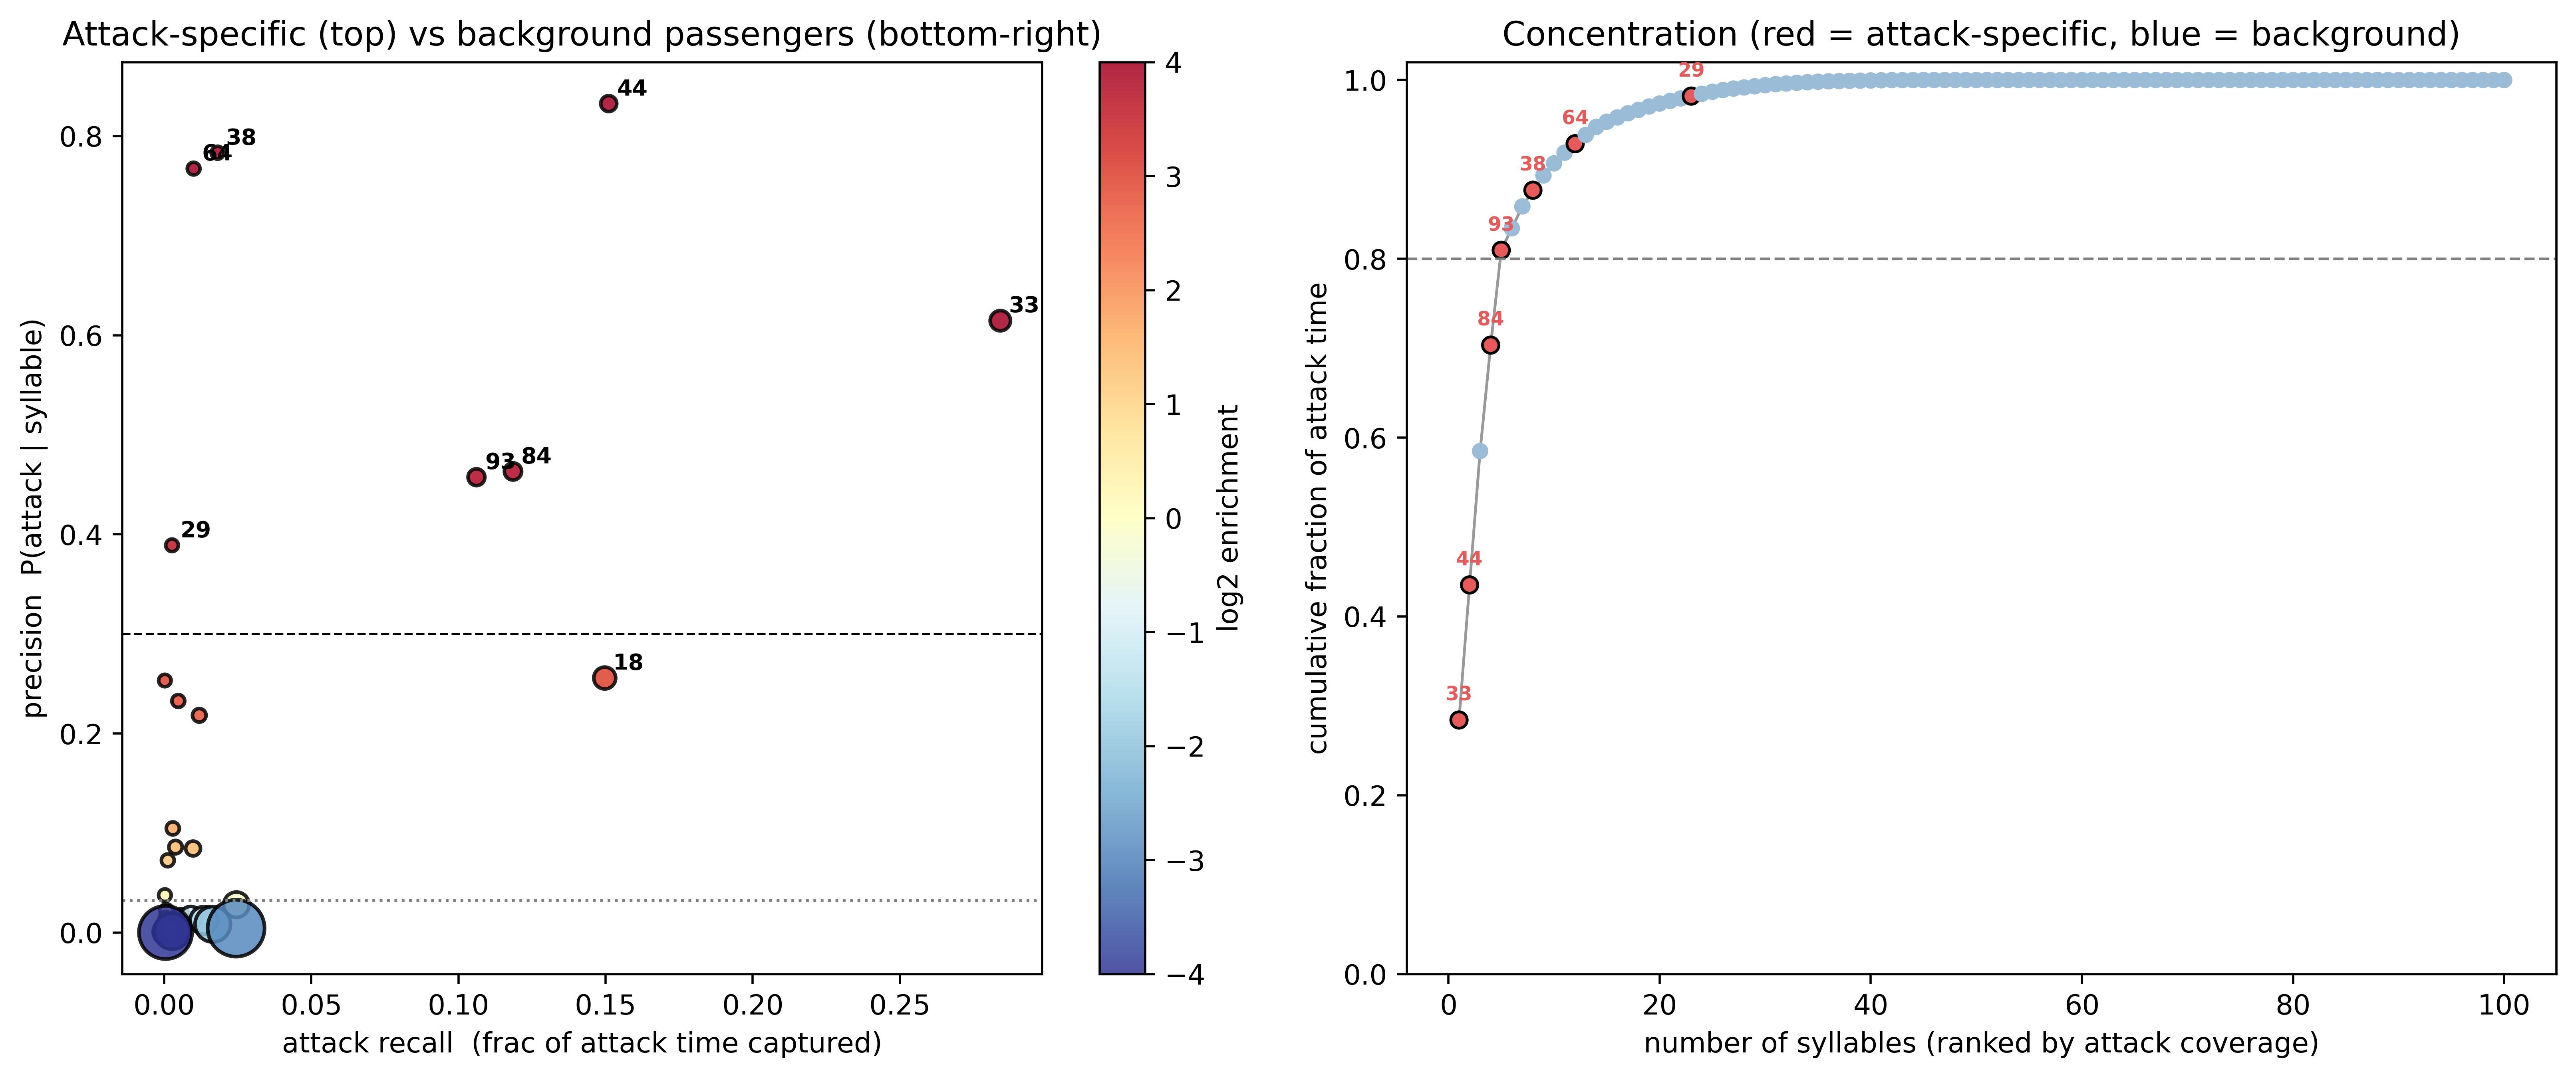

In [322]:
# =============================================================
# Effect size + attack concentration, with precision/recall separation
# (reuses S, A, base, n_syll, tab, DO_PERM)
# =============================================================
PREC_MIN   = 0.30   # min P(attack | syllable) to call a syllable "attack-specific"
ENRICH_MIN = 2.0    # min log2 enrichment (2 = 4x baseline)
PVAL       = 0.05

total_attack = int(A.sum())

eff = tab.copy()
eff["precision"]     = eff["P_attack_given_syll"]                                   # P(attack | syllable)
eff["attack_recall"] = eff["syllable"].map({k: ((S == k) & A).sum() / (total_attack + 1e-9)
                                            for k in range(n_syll)})                # frac of attack captured
eff["f1"] = 2 * eff["precision"] * eff["attack_recall"] / (eff["precision"] + eff["attack_recall"] + 1e-12)

# ---- FIX: define attack syllables by precision + enrichment (NOT recall / p-value) ----
psig = eff["p_perm"] if DO_PERM else pd.Series(0.0, index=eff.index)
is_attack = (eff["precision"] > PREC_MIN) & (eff["log2_enrich"] > ENRICH_MIN) & (psig < PVAL)
eff["specific"] = is_attack
attack_syllables = sorted(eff.loc[is_attack, "syllable"].astype(int).tolist())

print(f"total attack frames = {total_attack} | baseline attack rate = {base:.3f}")
print(f"p<0.05 syllables = {int((psig < PVAL).sum())}/{n_syll} (power-inflated)  |  "
      f"attack-SPECIFIC syllables = {len(attack_syllables)} -> {attack_syllables}\n")

cols = ["syllable", "corr_r", "log2_enrich", "precision", "attack_recall", "f1", "n_frames", "specific"]
if DO_PERM: cols.insert(3, "p_perm")
print("=== ranked by effect size (corr_r) ===")
print(eff.sort_values("corr_r", ascending=False)[cols].head(15).round(4).to_string(index=False))

# ---- combined detector: predict attack when frame is in an attack-specific syllable ----
pred = np.isin(S, attack_syllables)
tp = int((pred & A).sum())
P = tp / (pred.sum() + 1e-9); R = tp / (total_attack + 1e-9); F = 2 * P * R / (P + R + 1e-12)
print(f"\ncombined attack-syllable set as a detector:  precision {P:.3f} | recall {R:.3f} | F1 {F:.3f}")

# =============================================================
# figure: (1) precision-recall scatter  (2) concentration curve
# =============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), dpi=500)

# --- 1. precision vs recall: separates true attack syllables from big background states ---
sizes = 20 + 400 * eff["n_frames"] / eff["n_frames"].max()
sc = ax1.scatter(eff["attack_recall"], eff["precision"], s=sizes,
                 c=eff["log2_enrich"], cmap="RdYlBu_r", vmin=-4, vmax=4,
                 edgecolor=np.where(eff["specific"], "black", "none"), linewidth=1.3, alpha=0.85)
ax1.axhline(base, ls=":", color="gray", lw=1)                       # baseline precision
ax1.axhline(PREC_MIN, ls="--", color="black", lw=0.8)
for _, r in eff[eff["specific"] | (eff["attack_recall"] > 0.05)].iterrows():
    ax1.annotate(str(int(r["syllable"])), (r["attack_recall"], r["precision"]),
                 xytext=(3, 3), textcoords="offset points", fontsize=8, fontweight="bold")
ax1.set_xlabel("attack recall  (frac of attack time captured)")
ax1.set_ylabel("precision  P(attack | syllable)")
ax1.set_title("Attack-specific (top) vs background passengers (bottom-right)")
fig.colorbar(sc, ax=ax1).set_label("log2 enrichment")

# --- 2. concentration curve, colored by whether the syllable is attack-specific ---
byrec = eff.sort_values("attack_recall", ascending=False).reset_index(drop=True)
byrec["cum_recall"] = byrec["attack_recall"].cumsum()
ax2.plot(np.arange(1, n_syll + 1), byrec["cum_recall"].values, color="#999", lw=1, zorder=1)
ax2.scatter(np.arange(1, n_syll + 1), byrec["cum_recall"].values,
            c=np.where(byrec["specific"], "#E65A5A", "#9BBCD6"),
            edgecolor="black", linewidth=np.where(byrec["specific"], 1.0, 0), s=35, zorder=2)
ax2.axhline(0.8, ls="--", color="gray", lw=1); ax2.set_ylim(0, 1.02)
ax2.set_xlabel("number of syllables (ranked by attack coverage)")
ax2.set_ylabel("cumulative fraction of attack time")
ax2.set_title("Concentration (red = attack-specific, blue = background)")

# --- label the red dots on the concentration curve with their syllable id ---
byrec["rank"] = np.arange(1, len(byrec) + 1)
for _, r in byrec[byrec["specific"]].iterrows():
    ax2.annotate(str(int(r["syllable"])), (r["rank"], r["cum_recall"]),
                 xytext=(0, 7), textcoords="offset points", ha="center",
                 fontsize=7, color="#E65A5A", fontweight="bold", zorder=3)

# --- print: top-by-coverage ranking vs the precision-selected red set ---
k80 = int((byrec["cum_recall"] < 0.8).sum()) + 1      # first rank crossing 80%
print(f"\nTop {k80} syllables by COVERAGE reach 80% of attack time:")
print(byrec.loc[:k80-1, ["rank","syllable","attack_recall","cum_recall","specific"]].round(4).to_string(index=False))
print(f"\nRED / attack-SPECIFIC set (precision-selected) = {attack_syllables}")
print(f"  summed recall of the red set = {eff.loc[eff['specific'],'attack_recall'].sum():.3f}  (= combined-detector recall)")

plt.tight_layout(); plt.show()

                   n_mice  mean_delta  n_sig
treat                                       
Psilocybin              4     -0.0202      1
Psilocybin + Stim       1      0.0023      0
Saline                  4      0.0164      0

Significant mice:
  mouse      treat  baseline  joint   delta  p_fdr
1010832 Psilocybin    0.0689 0.0292 -0.0396 0.0128


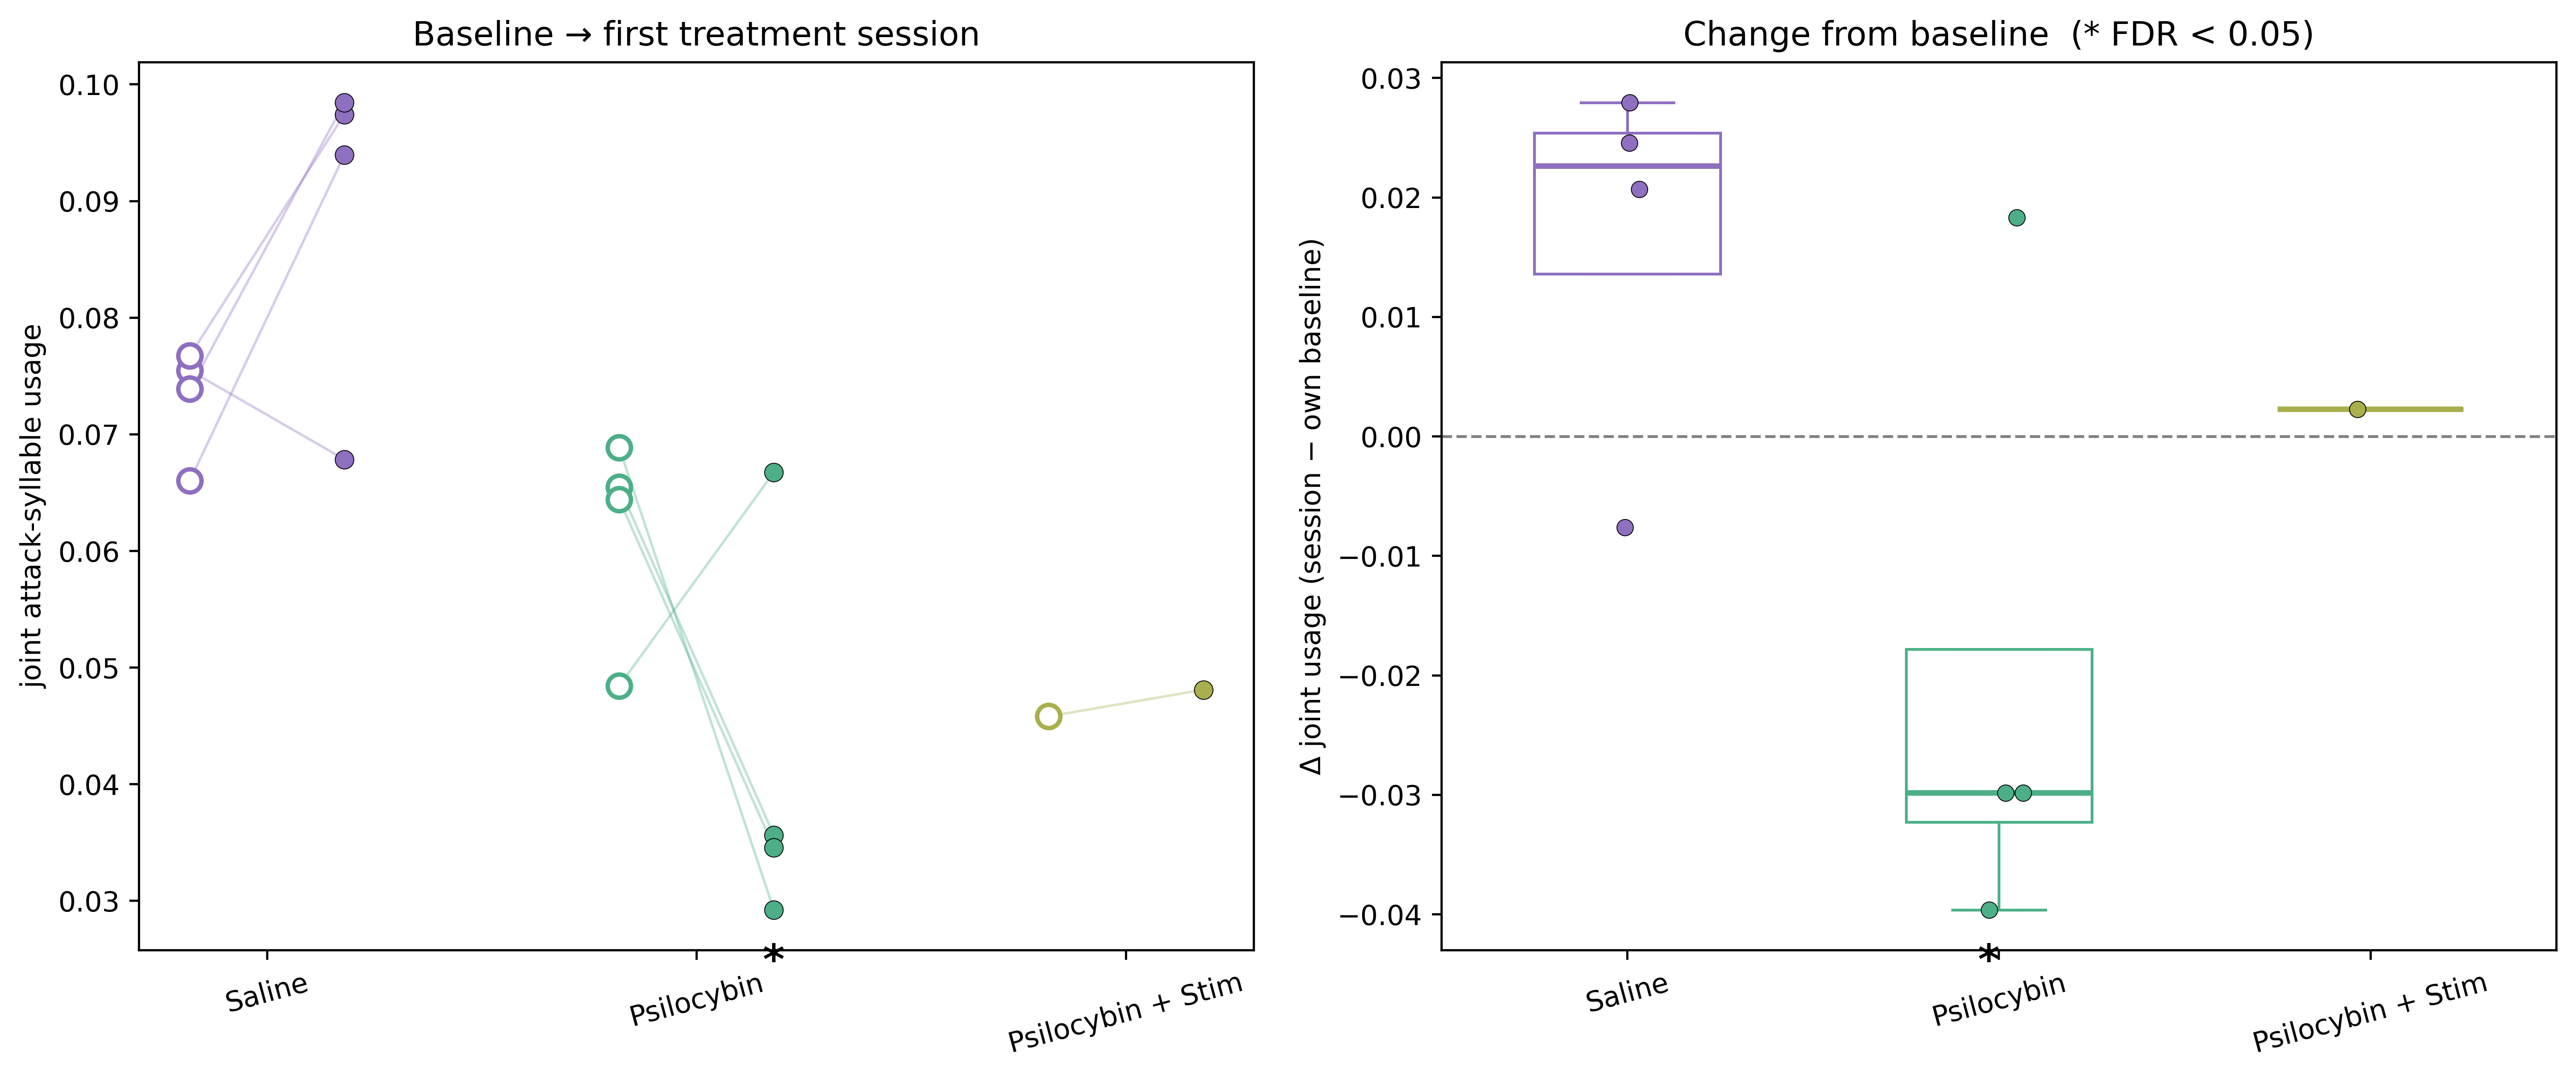

In [ ]:

from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

# attack syllables
ATTACK_SYLL = [33, 44, 38, 64]
usage_cols = [f"syll_{k}" for k in ATTACK_SYLL if f"syll_{k}" in df.columns]
missing = [k for k in ATTACK_SYLL if f"syll_{k}" not in df.columns]
if missing: print(f"WARNING: missing {missing}")

TREAT = {"maladaptive Saline": "Saline",
         "maladaptive Psilocybin": "Psilocybin",
         "maladaptive Psilocybin + Stim": "Psilocybin + Stim"}
TREAT_ORDER = ["Saline", "Psilocybin", "Psilocybin + Stim"]
tcol = {"Saline": "#8E6FC0", "Psilocybin": "#4CAF88", "Psilocybin + Stim": "#A8AF4C"}

# data + joint attack-syllable usage
d = df[df["group"].astype(str).str.startswith("maladaptive")].copy()
if "mouse" not in d.columns:
    d["mouse"] = d["mouse_group_id"].astype(str).str.split("_", n=1).str[0]

d["joint"] = d[usage_cols].sum(axis=1)

# own baseline
base_sess = d[d["group"] == "maladaptive baseline"].copy()
baseline = base_sess.groupby("mouse")["joint"].mean()

# first treatment session per mouse
after = d[d["group"].isin(TREAT)].copy()
after["treat"] = after["group"].map(TREAT)
after["baseline"] = after["mouse"].map(baseline)
after = after.dropna(subset=["baseline"])
after["delta"] = after["joint"] - after["baseline"]
after = after.sort_values("day").drop_duplicates("mouse", keep="first").copy()

# significance: first treatment session vs that mouse's baseline sessions
def mouse_p(r):
    b = base_sess.loc[base_sess["mouse"] == r["mouse"], "joint"].dropna().values
    return ttest_1samp(b, r["joint"]).pvalue if len(b) >= 2 and np.std(b, ddof=1) > 0 else np.nan

after["p"] = after.apply(mouse_p, axis=1)
after["p_fdr"] = np.nan
ok = after["p"].notna()
if ok.any():
    after.loc[ok, "p_fdr"] = multipletests(after.loc[ok, "p"], method="fdr_bh")[1]
after["sig"] = after["p_fdr"] < 0.05

print(after.groupby("treat").agg(
    n_mice=("mouse", "nunique"),
    mean_delta=("delta", "mean"),
    n_sig=("sig", "sum")).round(4).to_string())

print("\nSignificant mice:")
print(after.loc[after["sig"], ["mouse", "treat", "baseline", "joint", "delta", "p_fdr"]]
      .sort_values(["treat", "mouse"]).round(4).to_string(index=False))

# =============================================================
# FIGURE
# =============================================================
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5.5), dpi = 500)
yrA = max(after["joint"].max() - after["joint"].min(), 0.01)
yrB = max(after["delta"].max() - after["delta"].min(), 0.01)
rng = np.random.default_rng(0)

# A: baseline -> first treatment session
for ti, t in enumerate(TREAT_ORDER):
    sub = after[after["treat"] == t]
    xb, xa = ti - 0.18, ti + 0.18

    for _, r in sub.iterrows():
        axA.plot([xb, xa], [r["baseline"], r["joint"]],
                 color=tcol[t], alpha=.35, lw=.9, zorder=1)
        axA.scatter(xb, r["baseline"], facecolor="white", edgecolor=tcol[t],
                    s=70, lw=1.6, zorder=3)
        axA.scatter(xa, r["joint"], facecolor=tcol[t], edgecolor="black",
                    s=45, lw=.3, zorder=3)

        if r["sig"]:
            off = .04 * yrA * np.sign(r["delta"] if r["delta"] != 0 else 1)
            axA.text(xa, r["joint"] + off, "*", ha="center",
                     va="bottom" if off > 0 else "top",
                     fontsize=15, fontweight="bold")

axA.set_xticks(range(len(TREAT_ORDER)))
axA.set_xticklabels(TREAT_ORDER, rotation=15)
axA.set_ylabel("joint attack-syllable usage")
axA.set_title("Baseline → first treatment session")

# B: delta from own baseline
for ti, t in enumerate(TREAT_ORDER):
    sub = after[after["treat"] == t]
    vals = sub["delta"].values
    if not len(vals): continue

    x = rng.normal(ti, .05, len(sub))

    axB.boxplot([vals], positions=[ti], widths=.5, patch_artist=True, showfliers=False,
                boxprops=dict(facecolor="white", edgecolor=tcol[t]),
                medianprops=dict(color=tcol[t], lw=2),
                whiskerprops=dict(color=tcol[t]),
                capprops=dict(color=tcol[t]))

    axB.scatter(x, vals, color=tcol[t], edgecolor="black", s=35, lw=.3, zorder=3)

    for xi, (_, r) in zip(x, sub.iterrows()):
        if r["sig"]:
            off = .04 * yrB * np.sign(r["delta"] if r["delta"] != 0 else 1)
            axB.text(xi, r["delta"] + off, "*", ha="center",
                     va="bottom" if off > 0 else "top",
                     fontsize=15, fontweight="bold")

axB.axhline(0, ls="--", color="gray", lw=1)
axB.set_xticks(range(len(TREAT_ORDER)))
axB.set_xticklabels(TREAT_ORDER, rotation=15)
axB.set_ylabel("Δ joint usage (session − own baseline)")
axB.set_title("Change from baseline  (* FDR < 0.05)")

plt.tight_layout()
plt.show()

In [315]:
# =============================================================
# FINAL: attack-syllable set + combined-detector performance
# =============================================================
sub = eff[eff["specific"]].sort_values("attack_recall", ascending=False)
cols = ["syllable", "corr_r", "log2_enrich", "precision", "attack_recall", "n_frames"]
if DO_PERM: cols.insert(1, "p_perm")

print(f"ATTACK-SYLLABLE SET ({len(attack_syllables)}): {attack_syllables}\n")
print(sub[cols].round(4).to_string(index=False))

pred = np.isin(S, attack_syllables)
tp = int((pred & A).sum())
P = tp / (pred.sum() + 1e-9); R = tp / (A.sum() + 1e-9); F = 2 * P * R / (P + R + 1e-12)
print(f"\nCombined detector (frame in attack-syllable set  ->  predict attack):")
print(f"  precision = {P:.3f}   recall = {R:.3f}   F1 = {F:.3f}")
print(f"  captures {R*100:.1f}% of all attack time; "
      f"{P*100:.1f}% of predicted-attack frames are true attack "
      f"(vs {base*100:.1f}% baseline -> {P/base:.1f}x enrichment)")

ATTACK-SYLLABLE SET (7): [29, 33, 38, 44, 64, 84, 93]

 syllable  p_perm  corr_r  log2_enrich  precision  attack_recall  n_frames
       33   0.002  0.4055       4.2418     0.6146         0.2842     40395
       44   0.002  0.3475       4.6798     0.8326         0.1511     15853
       84   0.002  0.2224       3.8337     0.4632         0.1185     22360
       93   0.002  0.2089       3.8157     0.4574         0.1061     20270
       38   0.002  0.1163       4.5917     0.7833         0.0182      2026
       64   0.002  0.0853       4.5620     0.7673         0.0100      1139
       29   0.002  0.0300       3.5818     0.3890         0.0027       599

Combined detector (frame in attack-syllable set  ->  predict attack):
  precision = 0.588   recall = 0.691   F1 = 0.635
  captures 69.1% of all attack time; 58.8% of predicted-attack frames are true attack (vs 3.2% baseline -> 18.1x enrichment)


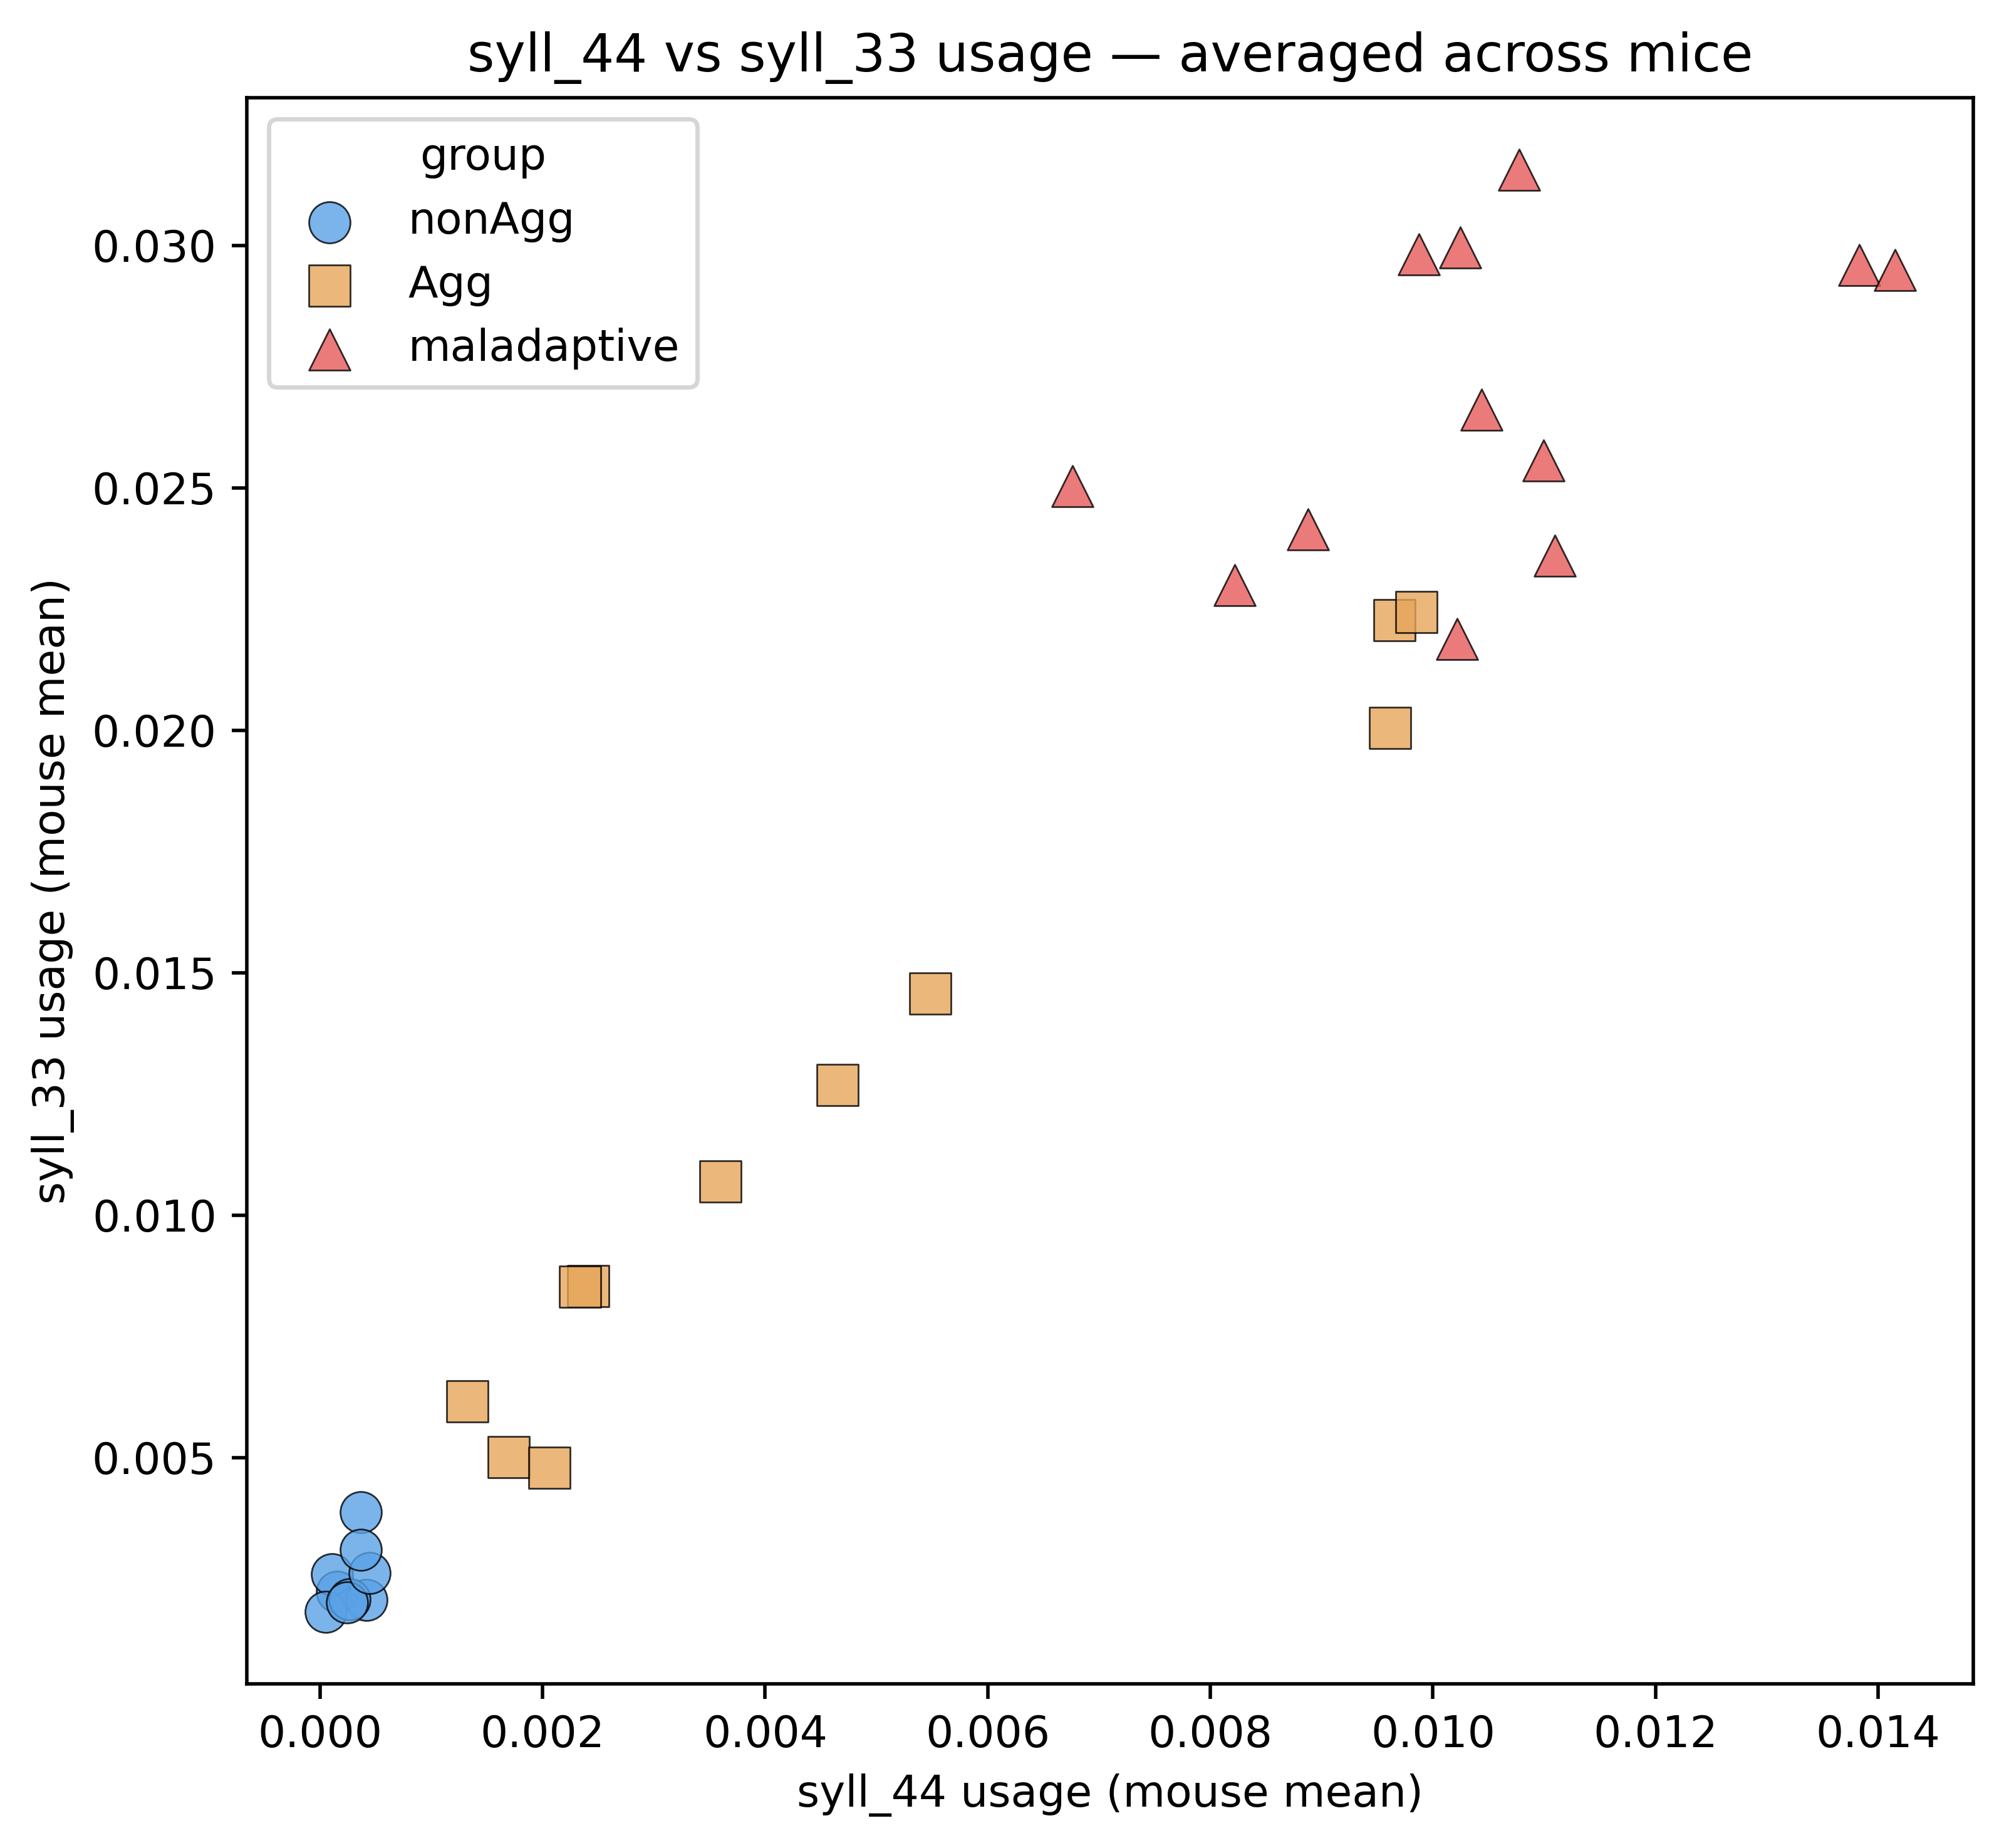

In [310]:
# which two syllables to compare
SX, SY = 44, 33
col_x, col_y = f"syll_{SX}", f"syll_{SY}"

group_colors  = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
group_markers = {"nonAgg": "o", "Agg": "s", "maladaptive": "^"}
group_order   = ["nonAgg", "Agg", "maladaptive"]

# baseline-only, then average each mouse's sessions -> one point per mouse
d = df[df["group"].isin(["nonAgg", "Agg", "maladaptive baseline"])].copy()
d["group_merged"] = d["group"].replace({"maladaptive baseline": "maladaptive"})
d = (d.groupby("mouse_group_id")
       .agg({col_x: "mean", col_y: "mean", "group_merged": "first"})
       .reset_index())

fig, ax = plt.subplots(figsize=(6.5, 6), dpi = 500)
for g in group_order:
    sub = d[d["group_merged"] == g]
    ax.scatter(sub[col_x], sub[col_y],
               label=g, color=group_colors[g], marker=group_markers[g],
               s=90, alpha=0.8, edgecolor="black", linewidth=0.4)

ax.set_xlabel(f"{col_x} usage (mouse mean)")
ax.set_ylabel(f"{col_y} usage (mouse mean)")
ax.set_title(f"{col_x} vs {col_y} usage — averaged across mice")
ax.legend(title="group", loc="best", frameon=True)
plt.tight_layout()
plt.show()

Attack usage columns: 5
Attack transition columns: 500
['trans_18_0', 'trans_18_1', 'trans_18_2', 'trans_18_3', 'trans_18_4', 'trans_18_5', 'trans_18_6', 'trans_18_7', 'trans_18_8', 'trans_18_9', 'trans_18_10', 'trans_18_11', 'trans_18_12', 'trans_18_13', 'trans_18_14', 'trans_18_15', 'trans_18_16', 'trans_18_17', 'trans_18_18', 'trans_18_19', 'trans_18_20', 'trans_18_21', 'trans_18_22', 'trans_18_23', 'trans_18_24', 'trans_18_25', 'trans_18_26', 'trans_18_27', 'trans_18_28', 'trans_18_29', 'trans_18_30', 'trans_18_31', 'trans_18_32', 'trans_18_33', 'trans_18_34', 'trans_18_35', 'trans_18_36', 'trans_18_37', 'trans_18_38', 'trans_18_39', 'trans_18_40', 'trans_18_41', 'trans_18_42', 'trans_18_43', 'trans_18_44', 'trans_18_45', 'trans_18_46', 'trans_18_47', 'trans_18_48', 'trans_18_49', 'trans_18_50', 'trans_18_51', 'trans_18_52', 'trans_18_53', 'trans_18_54', 'trans_18_55', 'trans_18_56', 'trans_18_57', 'trans_18_58', 'trans_18_59', 'trans_18_60', 'trans_18_61', 'trans_18_62', 'trans_18

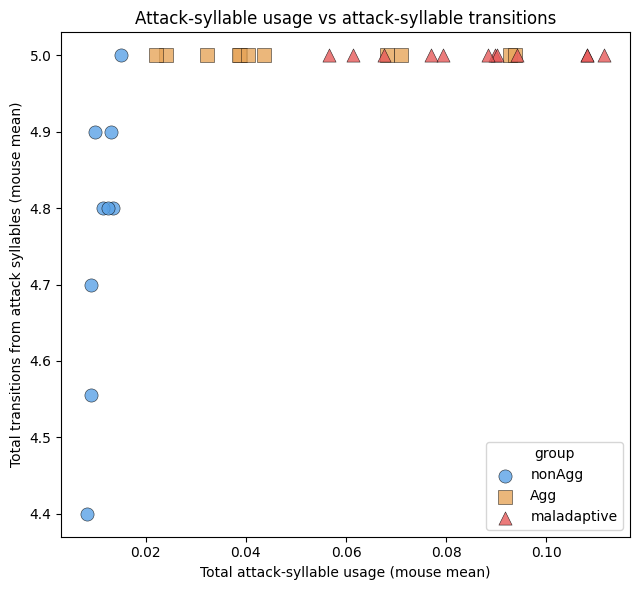

In [313]:
ATTACK_SYLL = [33, 44, 84, 93, 18]

group_colors  = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
group_markers = {"nonAgg": "o", "Agg": "s", "maladaptive": "^"}
group_order   = ["nonAgg", "Agg", "maladaptive"]

# syllable usage columns
attack_cols = [f"syll_{k}" for k in ATTACK_SYLL if f"syll_{k}" in df.columns]

# transitions FROM any attack syllable (includes attack→attack + attack→other)
trans_cols = []
for c in df.columns:
    nums = [int(x) for x in re.findall(r"\d+", c)]
    if "trans" in c.lower() and len(nums) >= 2:
        src, dst = nums[-2], nums[-1]
        if src in ATTACK_SYLL:
            trans_cols.append(c)

print(f"Attack usage columns: {len(attack_cols)}")
print(f"Attack transition columns: {len(trans_cols)}")
print(trans_cols)

# baseline only
d = df[df["group"].isin(["nonAgg", "Agg", "maladaptive baseline"])].copy()
d["group_merged"] = d["group"].replace({"maladaptive baseline": "maladaptive"})

# per-session totals
d["attack_usage"] = d[attack_cols].sum(axis=1)
d["attack_transitions"] = d[trans_cols].sum(axis=1)

# average sessions -> one point per mouse
d = (d.groupby("mouse_group_id")
       .agg(attack_usage=("attack_usage", "mean"),
            attack_transitions=("attack_transitions", "mean"),
            group_merged=("group_merged", "first"))
       .reset_index())

# plot
fig, ax = plt.subplots(figsize=(6.5, 6))

for g in group_order:
    sub = d[d["group_merged"] == g]
    ax.scatter(sub["attack_usage"], sub["attack_transitions"],
               label=g, color=group_colors[g], marker=group_markers[g],
               s=90, alpha=0.8, edgecolor="black", linewidth=0.4)

ax.set_xlabel("Total attack-syllable usage (mouse mean)")
ax.set_ylabel("Total transitions from attack syllables (mouse mean)")
ax.set_title("Attack-syllable usage vs attack-syllable transitions")
ax.legend(title="group", loc="best", frameon=True)

plt.tight_layout()
plt.show()